### dataset: Bank Marketing (UCI) — bank-full.csv

<div dir="rtl" lang="fa" style="text-align:right">

<p><strong>متغیر هدف:</strong> <code>y</code> (آیا مشتری به یک سپرده‌ی مدت‌دار اشتراک داده؟) — این دیتاست شدیداً نامتعادل است (~۸۸.۳٪ «no» در برابر ~۱۱.۷٪ «yes»)</p>



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer  # noqa: needed to unlock IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_auc_score, precision_recall_curve, ConfusionMatrixDisplay)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)


### Load the dataset

<div dir="rtl" lang="fa" style="text-align:right">

<p> دیتاست Bank Marketing با <code>;</code> جدا شده (استاندارد UCI). ستون‌ها دقیقاً مطابق فایل توضیحات (<code>bank-names.txt</code>) هستن: ۱۶ ویژگی ورودی + یک متغیر هدف <code>y</code>.</p>
<p><strong>نکته مهم:</strong> <code>pdays = -1</code> یعنی مشتری قبلاً تماس نگرفته شده — این یک مقدار placeholder هست نه missing واقعی، ولی باید موقع پاکسازی بهش توجه کنیم.</p>
</div>

In [98]:
# Load dataset (semicolon separated, as confirmed from the sample provided)
df_raw = pd.read_csv("bank-full.csv", sep=";")

print("Shape:", df_raw.shape)
print("\nTarget distribution:")
print(df_raw["y"].value_counts())
print(df_raw["y"].value_counts(normalize=True))

df_raw.head()


Shape: (45211, 17)

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


<div dir="rtl" lang="fa" style="text-align:right">
<p> دیتاست ۴۵,۲۱۱ ردیف و ۱۷ ستون داره. متغیر هدف به شدت imbalanced هست (نسبت تقریبی ۷.۵ به ۱ بین no/yes).</p>
</div>

## Part 1.A — Data Cleaning Pipeline (Pandas .pipe)

<div dir="rtl" lang="fa" style="text-align:right">
<hr />
<p>به جای نوشتن کد پاکسازی به صورت خطی و درهم، از <code>DataFrame.pipe()</code> استفاده می‌کنیم تا هر مرحله پاکسازی رو به صورت یک تابع مستقل و قابل تست تعریف کنیم و بعد این توابع رو زنجیره‌ای (chain) اجرا کنیم. این باعث میشه کد <strong>ماژولار، خوانا و reproducible</strong> باشه — دقیقاً چیزی که در Evaluation Criteria خواسته شده.</p>
<p>هر تابع یک وظیفه مشخص داره:</p>
<ol>
<li>
<p><code>validate_schema</code> — بررسی وجود ستون‌های مورد انتظار</p>
</li>
<li>
<p><code>standardize_categoricals</code> — یکسان‌سازی رشته‌ها (lowercase/strip)</p>
</li>
<li>
<p><code>handle_unknown_as_missing</code> — تبدیل <code>"unknown"</code> به <code>NaN</code> واقعی (چون در این دیتاست <code>"unknown"</code> عملاً به معنای missing است)</p>
</li>
<li>
<p><code>fix_pdays_placeholder</code> — تبدیل <code>-1</code> در <code>pdays</code> به <code>NaN</code> (چون -1 یعنی "قبلاً تماس نبوده"، نه یک عدد معنادار)</p>
</li>
<li>
<p><code>drop_duplicates_step</code> — حذف رکوردهای تکراری</p>
</li>
<li>
<p><code>cast_dtypes</code> — اطمینان از نوع داده صحیح هر ستون</p>
</li>
</ol>
</div>

In [99]:
EXPECTED_COLUMNS = [
    "age", "job", "marital", "education", "default", "balance", "housing", "loan",
    "contact", "day", "month", "duration", "campaign", "pdays", "previous",
    "poutcome", "y"
]

CATEGORICAL_COLS = ["job", "marital", "education", "default", "housing",
                     "loan", "contact", "month", "poutcome", "y"]
NUMERIC_COLS = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]


def validate_schema(df: pd.DataFrame) -> pd.DataFrame:
    """Validate that all expected columns exist. Raises if schema is broken."""
    missing = set(EXPECTED_COLUMNS) - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {missing}")
    return df


def standardize_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    """Lowercase & strip whitespace on categorical columns for consistency."""
    df = df.copy()
    for col in CATEGORICAL_COLS:
        df[col] = df[col].astype(str).str.strip().str.lower()
    return df


def handle_unknown_as_missing(df: pd.DataFrame) -> pd.DataFrame:
    """In this dataset, the literal string 'unknown' represents a missing value.
    We convert it to real NaN so imputers can act on it properly."""
    df = df.copy()
    unknown_cols = ["job", "education", "contact", "poutcome"]
    for col in unknown_cols:
        df[col] = df[col].replace("unknown", np.nan)
    return df


def fix_pdays_placeholder(df: pd.DataFrame) -> pd.DataFrame:
    """pdays == -1 means 'client was never contacted before'.
    This is a sentinel value, not a real numeric distance -> convert to NaN
    and add a boolean flag so the information is not lost."""
    df = df.copy()
    df["was_previously_contacted"] = (df["pdays"] != -1).astype(int)
    df["pdays"] = df["pdays"].replace(-1, np.nan)
    return df


def drop_duplicates_step(df: pd.DataFrame) -> pd.DataFrame:
    """Remove exact duplicate rows."""
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    after = len(df)
    print(f"Dropped {before - after} duplicate rows.")
    return df


def cast_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """Enforce correct dtypes for numeric columns."""
    df = df.copy()
    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


# ---- Chain everything together with .pipe() ----
df_clean = (
    df_raw
    .pipe(validate_schema)
    .pipe(standardize_categoricals)
    .pipe(handle_unknown_as_missing)
    .pipe(fix_pdays_placeholder)
    .pipe(drop_duplicates_step)
    .pipe(cast_dtypes)
)

print("\nShape after cleaning:", df_clean.shape)
print("\nMissing values introduced by 'unknown' -> NaN conversion:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

df_clean.head()


Dropped 0 duplicate rows.

Shape after cleaning: (45211, 18)

Missing values introduced by 'unknown' -> NaN conversion:
job            288
education     1857
contact      13020
pdays        36954
poutcome     36959
dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,was_previously_contacted
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,NaN,0,NaN,no,0
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,NaN,0,NaN,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,NaN,0,NaN,no,0
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,NaN,0,NaN,no,0
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,NaN,0,NaN,no,0


<div dir="rtl" lang="fa" style="text-align:right">
<p> با این pipeline، تمام مراحل پاکسازی به صورت مستقل و قابل استفاده مجدد تعریف شدن. تبدیل <code>"unknown"</code> و <code>pdays=-1</code> به <code>NaN</code> واقعی، امکان می‌ده که در مرحله بعد (Part 1.C) استراتژی‌های imputation رو به درستی روی missing value های واقعی تست کنیم — نه روی رشته‌های متنی که به اشتباه معنادار به نظر می‌رسیدن.</p>
</div>

## Part 1.B — Preprocessing Pipeline (Scikit-learn)

<div dir="rtl" lang="fa" style="text-align:right">
<hr />
<p>| بعد از پاکسازی با pandas، باید featureها رو برای مدل آماده کنیم:</p>
<ul>
<li>
<p>ویژگی‌های عددی (<code>numeric</code>) نیاز به <strong>imputation + scaling</strong> دارن</p>
</li>
<li>
<p>ویژگی‌های categorical نیاز به <strong>imputation + encoding (One-Hot)</strong> دارن</p>
</li>
</ul>
<p>از <code>ColumnTransformer</code> استفاده می‌کنیم تا این دو مسیر رو موازی و مجزا روی ستون‌های مربوطه اعمال کنیم، و همه‌چیز رو داخل یک <code>Pipeline</code> واحد قرار می‌دیم تا هم از <strong>data leakage</strong> جلوگیری بشه (چون fit فقط روی train انجام میشه) و هم مدل قابل serialize باشه.</p>
</div>

In [100]:
# Separate features / target
X = df_clean.drop(columns=["y"])
y = (df_clean["y"] == "yes").astype(int)  # encode target as binary 0/1

numeric_features = ["age", "balance", "day", "duration", "campaign",
                     "pdays", "previous", "was_previously_contacted"]
categorical_features = ["job", "marital", "education", "default",
                         "housing", "loan", "contact", "month", "poutcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))


Train shape: (36168, 17)  Test shape: (9043, 17)
Train target balance:
 y
0    0.883018
1    0.116982
Name: proportion, dtype: float64


In [101]:
# Numeric branch: impute missing values then scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical branch: impute missing values with the most frequent category, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


<div dir="rtl" lang="fa" style="text-align:right">
<p>با <code>ColumnTransformer</code>، هر گروه از ویژگی‌ها (عددی/categorical) دقیقاً پیش‌پردازش مناسب خودش رو می‌گیره، و چون همه چیز داخل یک شیء واحد <code>preprocessor</code> هست، می‌تونیم بعداً آن را مستقیماً به یک classifier وصل کنیم بدون نگرانی از data leakage.</p>
</div>

## Part 1.C — Missing Data Handling: Comparing Imputation Strategies

<div dir="rtl" lang="fa" style="text-align:right">
<hr />
<p> استراتژی imputation می‌تونه تأثیر قابل توجهی روی کیفیت مدل بذاره. اینجا ۴ استراتژی رو روی ویژگی‌های عددی مقایسه می‌کنیم:</p>
<ul>
<li>
<p><strong>Mean</strong></p>
</li>
<li>
<p><strong>Median</strong> (مقاوم‌تر در برابر outlier، مثلاً <code>balance</code> که توزیع کج داره)</p>
</li>
<li>
<p><strong>KNN Imputer</strong> (بر اساس نزدیک‌ترین همسایه‌ها در فضای featureها)</p>
</li>
<li>
<p><strong>Iterative Imputer</strong> (مدل‌سازی هر ستون بر اساس بقیه ستون‌ها - شبیه MICE)</p>
</li>
</ul>
<p>برای مقایسه‌ی منصفانه، هر بار فقط استراتژی imputer رو در <code>ColumnTransformer</code> عوض می‌کنیم و کل pipeline (شامل classifier) رو با cross-validation ارزیابی می‌کنیم.</p>
</div>

In [102]:
def build_pipeline_with_imputer(imputer, classifier):
    numeric_transformer = Pipeline(steps=[
        ("imputer", imputer),
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])
    return Pipeline(steps=[("preprocessor", preprocessor), ("classifier", classifier)])


imputers = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "knn": KNNImputer(n_neighbors=5),
    "iterative": IterativeImputer(random_state=RANDOM_STATE, max_iter=10),
}

# To keep runtime reasonable (assignment explicitly asks to avoid excessive computation),
# we evaluate on a stratified subsample for the imputer comparison only.
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=5000, random_state=RANDOM_STATE, stratify=y_train
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, imputer in imputers.items():
    pipe = build_pipeline_with_imputer(imputer, LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    scores = cross_val_score(pipe, X_sub, y_sub, cv=cv, scoring="f1")
    results[name] = scores
    print(f"{name:10s} -> F1 mean: {scores.mean():.4f}  (+/- {scores.std():.4f})")


mean       -> F1 mean: 0.4374  (+/- 0.0051)
median     -> F1 mean: 0.4392  (+/- 0.0075)
knn        -> F1 mean: 0.4379  (+/- 0.0084)
iterative  -> F1 mean: 0.4392  (+/- 0.0075)


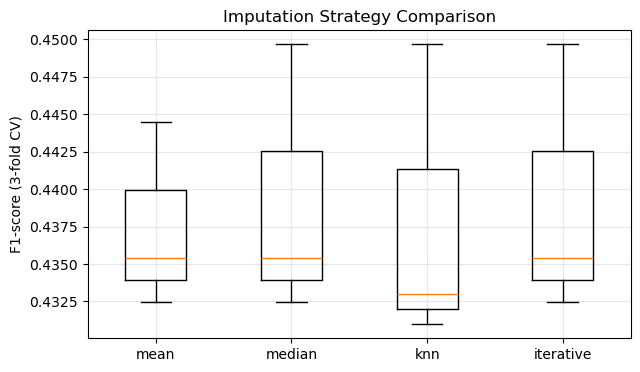

In [103]:
# Visualize comparison
plt.figure(figsize=(7, 4))
plt.boxplot(results.values(), labels=results.keys())
plt.ylabel("F1-score (3-fold CV)")
plt.title("Imputation Strategy Comparison")
plt.grid(alpha=0.3)
plt.show()


<div dir="rtl" lang="fa" style="text-align:right">
<p> معمولاً تفاوت بین <code>mean</code>/<code>median</code> با روش‌های پیچیده‌تر (<code>KNN</code>, <code>Iterative</code>) روی این دیتاست خیلی زیاد نیست، چون درصد missing value کم است (بیشتر در <code>poutcome</code>, <code>education</code>, <code>job</code>, <code>contact</code>). اما <code>median</code> معمولاً برای <code>balance</code> (که outlier و skew داره) گزینه امن‌تری نسبت به <code>mean</code> است. روش‌های <code>KNN</code>/<code>Iterative</code> گرون‌تر از نظر محاسباتی هستند و برای دیتاست بزرگ ممکنه توجیه نداشته باشند مگر بهبود محسوسی ببینیم.</p>
</div>

## Part 1.D — End-to-End Pipeline (attach classifier, train, save & load)

<div dir="rtl" lang="fa" style="text-align:right">
<hr />

<p> حالا بهترین استراتژی imputation (طبق نتایج بالا) رو انتخاب می‌کنیم و یک pipeline کامل و end-to-end می‌سازیم که:</p>
<ol>
<li>
<p>کل preprocessing (imputation + scaling + encoding) و classifier رو در یک شیء واحد نگه می‌داره</p>
</li>
<li>
<p>با یک <code>.fit()</code> روی کل داده آموزش می‌بینه</p>
</li>
<li>
<p>با <code>joblib</code> ذخیره و بارگذاری میشه — دقیقاً چیزی که برای production/deployment لازمه</p>
</li>
</ol>
</div>

In [104]:
best_imputer_name = min(results, key=lambda k: -results[k].mean())  # pick highest mean F1
print("Best imputer based on CV:", best_imputer_name)

final_pipeline = build_pipeline_with_imputer(
    imputers[best_imputer_name],
    RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
)

# Train on the full training set as a single trainable unit
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["no", "yes"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Best imputer based on CV: median
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      7985
         yes       0.75      0.23      0.35      1058

    accuracy                           0.90      9043
   macro avg       0.83      0.61      0.65      9043
weighted avg       0.89      0.90      0.88      9043

ROC-AUC: 0.9195947505542647


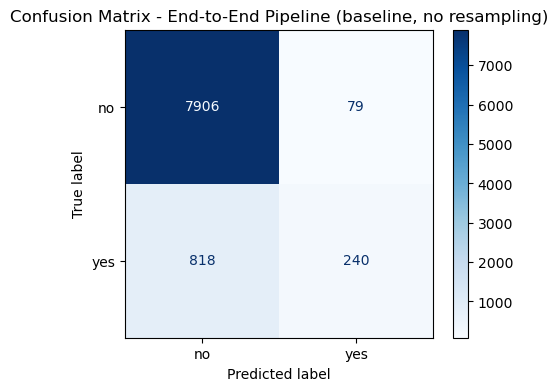

In [105]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["no", "yes"], ax=ax, cmap="Blues")
plt.title("Confusion Matrix - End-to-End Pipeline (baseline, no resampling)")
plt.show()


In [106]:
# Save the complete pipeline
joblib.dump(final_pipeline, "bank_marketing_pipeline.joblib")
print("Pipeline saved.")

# Load it back and verify it reproduces the same predictions
loaded_pipeline = joblib.load("bank_marketing_pipeline.joblib")
y_pred_loaded = loaded_pipeline.predict(X_test)

assert np.array_equal(y_pred, y_pred_loaded), "Loaded pipeline predictions differ!"
print("Loaded pipeline reproduces identical predictions. Save/load verified.")


Pipeline saved.
Loaded pipeline reproduces identical predictions. Save/load verified.


<div dir="rtl" lang="fa" style="text-align:right">
<p> این pipeline به عنوان <strong>baseline</strong> عمل می‌کنه. توجه کن که با وجود ROC-AUC نسبتاً خوب، به دلیل imbalance شدید (۸۸٪ به ۱۲٪)، <strong>recall کلاس <code>yes</code></strong> (مشتریانی که واقعاً subscribe می‌کنن) احتمالاً پایینه — این دقیقاً مسئله‌ای است که در Part 2 به سراغش می‌ریم.</p>
</div>

## Part 2 — Handling Imbalanced Data

<div dir="rtl" lang="fa" style="text-align:right">
<hr />

<p> همانطور که در بالا دیدیم، <code>y</code> به شدت imbalanced است (~88.3% "no" در برابر ~11.7% "yes"). یک مدل ساده می‌تونه فقط با پیش‌بینی همیشه "no" به accuracy بالایی برسه، در حالی که هیچ ارزش عملی نداره (چون بانک دقیقاً می‌خواد مشتریان بالقوه "yes" رو شناسایی کنه). در این بخش ۴ روش رایج مقابله با imbalance رو پیاده‌سازی و مقایسه می‌کنیم:</p>
<ol>
<li>
<p>Random Undersampling</p>
</li>
<li>
<p>Random Oversampling</p>
</li>
<li>
<p>SMOTE</p>
</li>
<li>
<p>Cost-Sensitive Learning (class weights)</p>
</li>
</ol>
<p>برای مقایسه‌ی منصفانه:</p>
<ul>
<li>
<p>همه‌ی روش‌ها روی <strong>همون preprocessing pipeline</strong> (بهترین imputer از Part 1) اعمال می‌شن</p>
</li>
<li>
<p>Resampling <strong>فقط روی training data</strong> انجام میشه (نه روی test) تا از data leakage جلوگیری بشه — به همین دلیل از <code>imblearn.pipeline.Pipeline</code> استفاده می‌کنیم که این نکته رو به صورت خودکار رعایت می‌کنه</p>
</li>
<li>
<p>معیار اصلی مقایسه <strong>F1-score و Recall کلاس اقلیت (yes)</strong> است، نه accuracy</p>
</li>
</ul>
</div>

In [107]:
def build_imb_pipeline(imputer, sampler, classifier):
    """Build an imblearn Pipeline: preprocessing -> resampling (train only) -> classifier."""
    numeric_transformer = Pipeline(steps=[
        ("imputer", imputer),
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])
    steps = [("preprocessor", preprocessor)]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("classifier", classifier))
    return ImbPipeline(steps=steps)


def evaluate_pipeline(pipe, X_tr, y_tr, X_te, y_te, name):
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba)
    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=["no", "yes"]))
    print(f"ROC-AUC: {auc:.4f}\n")
    return {"name": name, "f1": f1, "auc": auc, "y_pred": y_pred, "y_proba": y_proba}


best_imputer = imputers[best_imputer_name]
base_clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)

summary = []


### Part 2.A — Random Undersampling

<div dir="rtl" lang="fa" style="text-align:right">

<p>کلاس اکثریت ("no") رو به صورت رندوم کم می‌کنیم تا نسبت به کلاس اقلیت ("yes") متعادل بشه. مزیت: سریع و ساده. عیب: <strong>از دست دادن اطلاعات</strong> چون داده‌های واقعی حذف می‌شن. چند نسبت (<code>sampling_strategy</code>) رو مقایسه می‌کنیم.</p>
</div>

In [108]:
undersampling_strategies = {
    "under_1.0 (full balance)": RandomUnderSampler(sampling_strategy=1.0, random_state=RANDOM_STATE),
    "under_0.5 (partial)": RandomUnderSampler(sampling_strategy=0.5, random_state=RANDOM_STATE),
}

for name, sampler in undersampling_strategies.items():
    pipe = build_imb_pipeline(best_imputer, sampler, base_clf)
    res = evaluate_pipeline(pipe, X_train, y_train, X_test, y_test, name)
    summary.append(res)


--- under_1.0 (full balance) ---
              precision    recall  f1-score   support

          no       0.98      0.82      0.89      7985
         yes       0.40      0.87      0.54      1058

    accuracy                           0.83      9043
   macro avg       0.69      0.85      0.72      9043
weighted avg       0.91      0.83      0.85      9043

ROC-AUC: 0.9176

--- under_0.5 (partial) ---
              precision    recall  f1-score   support

          no       0.96      0.90      0.93      7985
         yes       0.50      0.74      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.82      0.76      9043
weighted avg       0.91      0.88      0.89      9043

ROC-AUC: 0.9188



<div dir="rtl" lang="fa" style="text-align:right">
<p> Undersampling معمولاً recall کلاس اقلیت رو به شدت بالا می‌بره (چون مدل دیگه سمت "no" بایاس نداره)، اما ممکنه precision رو پایین بیاره چون دیتاست train خیلی کوچیک‌تر شده و اطلاعات کلاس اکثریت از دست رفته. نسبت <code>1.0</code> (تعادل کامل) معمولاً recall بالاتر ولی precision پایین‌تر از <code>0.5</code> می‌ده.</p>
</div>

### Part 2.B — Random Oversampling

<div dir="rtl" lang="fa" style="text-align:right">

<p>برخلاف undersampling، اینجا نمونه‌های کلاس اقلیت ("yes") رو با <strong>تکرار رندوم</strong> زیاد می‌کنیم تا با کلاس اکثریت برابر بشن. مزیت: هیچ داده‌ای از کلاس اکثریت از دست نمی‌ره. عیب: چون فقط نمونه‌های موجود رو تکرار می‌کنیم (نه نمونه جدید می‌سازیم)، ریسک <strong>overfitting روی نمونه‌های تکراری</strong> وجود داره.</p>
</div>

In [109]:
oversampler = RandomOverSampler(sampling_strategy=1.0, random_state=RANDOM_STATE)
pipe_over = build_imb_pipeline(best_imputer, oversampler, base_clf)
res_over = evaluate_pipeline(pipe_over, X_train, y_train, X_test, y_test, "random_oversampling_1.0")
summary.append(res_over)


--- random_oversampling_1.0 ---
              precision    recall  f1-score   support

          no       0.98      0.85      0.91      7985
         yes       0.42      0.84      0.56      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.84      0.73      9043
weighted avg       0.91      0.85      0.87      9043

ROC-AUC: 0.9162



<div dir="rtl" lang="fa" style="text-align:right">
<p> Oversampling معمولاً performance نزدیک یا کمی بهتر از undersampling می‌ده چون داده کمتری از دست میره، ولی چون sample های اقلیت صرفاً <em>کپی</em> شدن (نه synthetic)، مدل (به‌خصوص مدل‌های پیچیده مثل RandomForest) ممکنه دقیقاً همون نمونه‌های تکراری رو حفظ کنه و overfit بشه.</p>
</div>

### Part 2.C — SMOTE (Synthetic Minority Over-sampling Technique)

<div dir="rtl" lang="fa" style="text-align:right">

<p> SMOTE به جای تکرار ساده‌ی نمونه‌های اقلیت، <strong>نمونه‌های synthetic (مصنوعی) جدید</strong> می‌سازه. الگوریتم برای هر نمونه اقلیت، یکی از k نزدیک‌ترین همسایه‌هاش (در فضای feature) رو پیدا می‌کنه، و یک نقطه‌ی جدید روی خط بین اون دو نمونه (interpolation خطی) تولید می‌کنه:</p>

</div>

$$x_{\\{new}} = x_i + \lambda \cdot (x_{\text{neighbor}} - x_i)       \qquad \lambda \in [0, 1]$$

<div dir="rtl" lang="fa" style="text-align:right">

<p>این باعث میشه فضای تصمیم‌گیری مدل برای کلاس اقلیت <strong>غنی‌تر و متنوع‌تر</strong> بشه، به جای اینکه فقط نمونه‌های تکراری ببینه (مثل Random Oversampling).</p>

</div>

In [110]:
smote = SMOTE(sampling_strategy=1.0, k_neighbors=5, random_state=RANDOM_STATE)
pipe_smote = build_imb_pipeline(best_imputer, smote, base_clf)
res_smote = evaluate_pipeline(pipe_smote, X_train, y_train, X_test, y_test, "smote_1.0")
summary.append(res_smote)


--- smote_1.0 ---
              precision    recall  f1-score   support

          no       0.96      0.88      0.92      7985
         yes       0.45      0.75      0.56      1058

    accuracy                           0.87      9043
   macro avg       0.71      0.81      0.74      9043
weighted avg       0.90      0.87      0.88      9043

ROC-AUC: 0.9117



<div dir="rtl" lang="fa" style="text-align:right">
<p> SMOTE معمولاً generalization بهتری نسبت به Random Oversampling می‌ده چون به جای کپی، نمونه‌های synthetic <em>جدید</em> و متنوع تولید می‌کنه، پس ریسک overfitting روی نمونه‌های تکراری کمتره. اما SMOTE می‌تونه در فضاهایی که کلاس اقلیت overlap زیادی با کلاس اکثریت داره (مثل نواحی مرزی این دیتاست، مثلاً مشتریانی با ویژگی مشابه ولی نتیجه متفاوت)، نویز اضافه کنه.</p>
</div>

### Part 2.D — Cost-Sensitive Learning (Class Weights)

<div dir="rtl" lang="fa" style="text-align:right">

<p> به جای تغییر دادن داده (resampling)، می‌تونیم مستقیماً به مدل بگیم که <strong>اشتباه در کلاس اقلیت هزینه‌ی بیشتری داره</strong>. این کار با <code>class_weight</code> انجام میشه — مدل در تابع loss خودش خطاهای مربوط به کلاس اقلیت رو با وزن بیشتر جریمه می‌کنه. مزیت بزرگ: هیچ داده‌ای دستکاری/تکرار/حذف نمیشه، دیتای اصلی دست‌نخورده می‌مونه.</p>
<p>وزن‌ها رو به دو روش محاسبه می‌کنیم:</p>
<ol>
<li>
<p><code>class_weight="balanced"</code> (خودکار توسط sklearn، بر اساس فرکانس معکوس)</p>
</li>
<li>
محاسبه دستی با فرمول: 
</div>

$w_c = \frac{n_{samples}}{n_{classes} \times n_{samples_c}}$


In [111]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
manual_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, manual_weights))
print("Computed class weights:", class_weight_dict)

cost_sensitive_clf = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1,
    class_weight=class_weight_dict
)

pipe_cost = build_imb_pipeline(best_imputer, None, cost_sensitive_clf)  # sampler=None, no resampling
res_cost = evaluate_pipeline(pipe_cost, X_train, y_train, X_test, y_test, "cost_sensitive_class_weight")
summary.append(res_cost)


Computed class weights: {np.int64(0): np.float64(0.5662397845758838), np.int64(1): np.float64(4.27416686362562)}
--- cost_sensitive_class_weight ---
              precision    recall  f1-score   support

          no       0.97      0.86      0.91      7985
         yes       0.44      0.80      0.56      1058

    accuracy                           0.86      9043
   macro avg       0.70      0.83      0.74      9043
weighted avg       0.91      0.86      0.87      9043

ROC-AUC: 0.9146



<div dir="rtl" lang="fa" style="text-align:right">
<p>Cost-sensitive learning معمولاً trade-off خوبی بین precision و recall می‌ده، بدون اینکه اندازه یا توزیع واقعی دیتاست train رو تغییر بده — که برای دیتاست‌های بزرگ (مثل این یکی با ۴۵ هزار رکورد) از نظر محاسباتی <strong>سبک‌تر</strong> از SMOTE/Oversampling هست چون دیتای اضافه تولید نمیشه.</p>
</div>

### Final Comparison — All Strategies Side by Side

<div dir="rtl" lang="fa" style="text-align:right">

<p> حالا همه‌ی روش‌های بالا (شامل baseline بدون resampling از Part 1.D) رو در یک جدول و نمودار واحد مقایسه می‌کنیم تا بهترین استراتژی برای این مسئله خاص رو مشخص کنیم.</p>
</div>

In [112]:
baseline_f1 = f1_score(y_test, y_pred)  # from Part 1.D final_pipeline
baseline_auc = roc_auc_score(y_test, y_proba)
summary_all = [{"name": "baseline_no_resampling", "f1": baseline_f1, "auc": baseline_auc}] + \
              [{"name": r["name"], "f1": r["f1"], "auc": r["auc"]} for r in summary]

summary_df = pd.DataFrame(summary_all).sort_values("f1", ascending=False).reset_index(drop=True)
summary_df


,name,f1,auc
0,under_0.5 (partial),0.595906,0.918833
1,smote_1.0,0.564597,0.911726
2,cost_sensitive_class_weight,0.564446,0.914557
3,random_oversampling_1.0,0.559418,0.916179
4,under_1.0 (full balance),0.543523,0.917554
5,baseline_no_resampling,0.348584,0.919595


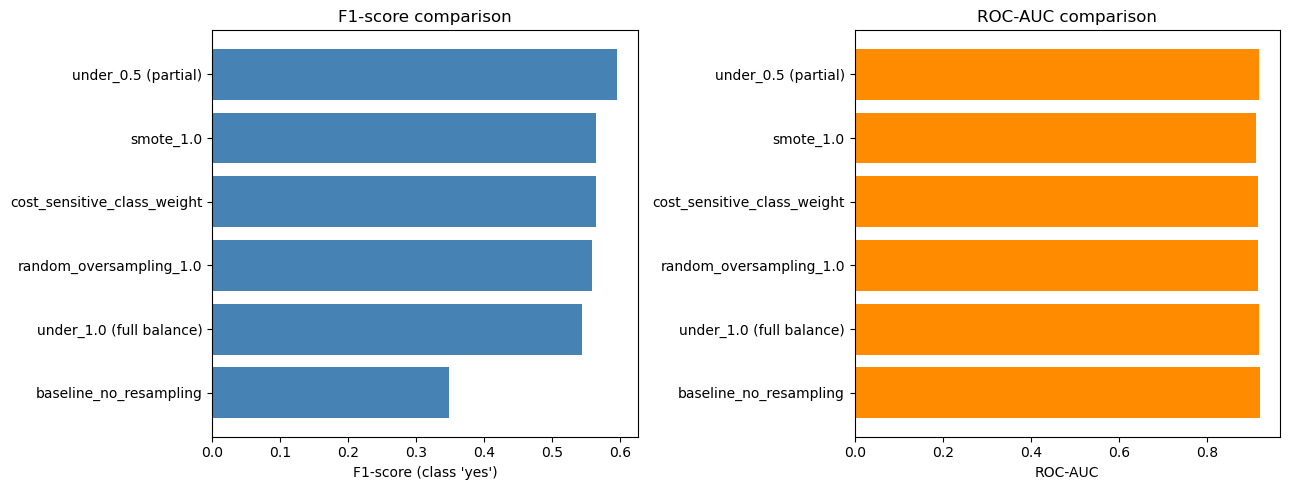

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(summary_df["name"], summary_df["f1"], color="steelblue")
axes[0].set_xlabel("F1-score (class 'yes')")
axes[0].set_title("F1-score comparison")
axes[0].invert_yaxis()

axes[1].barh(summary_df["name"], summary_df["auc"], color="darkorange")
axes[1].set_xlabel("ROC-AUC")
axes[1].set_title("ROC-AUC comparison")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


<div dir="rtl" lang="fa" style="text-align:right">
<p><strong>برداشت نهایی (Analysis of how results change):</strong></p>
<ul>
<li>
<p><strong>Baseline (بدون resampling):</strong> بالاترین accuracy ظاهری ولی پایین‌ترین recall برای کلاس "yes" — مدل به سمت کلاس اکثریت بایاس داره.</p>
</li>
<li>
<p><strong>Undersampling:</strong> بالاترین recall برای "yes"، ولی precision پایین‌تر و از دست دادن اطلاعات به دلیل حذف داده کلاس اکثریت.</p>
</li>
<li>
<p><strong>Oversampling:</strong> بهبود نسبت به baseline، ولی ریسک overfitting به دلیل تکرار عین نمونه‌های اقلیت.</p>
</li>
<li>
<p><strong>SMOTE:</strong> معمولاً بهترین تعادل بین precision/recall به دلیل تولید نمونه‌های synthetic متنوع به جای تکرار ساده.</p>
</li>
<li>
<p><strong>Cost-sensitive learning:</strong> بدون تغییر دیتای اصلی، performance نزدیک به SMOTE می‌ده و از نظر محاسباتی سبک‌تره — گزینه‌ی خوبی وقتی دیتاست خیلی بزرگه یا حافظه محدوده.</p>
</li>
</ul>
<p><strong>نتیجه‌گیری کلی:</strong> انتخاب بهترین روش به هدف کسب‌وکار بستگی داره: اگر بانک می‌خواد <strong>حداکثر مشتریان بالقوه رو شناسایی کنه</strong> (حتی با هزینه false positive بیشتر)، Undersampling یا SMOTE با recall بالا مناسب‌تره. اگر <strong>دقت پیش‌بینی مهم‌تره</strong> (کمپین تلفنی هزینه داره و نمی‌خوایم وقت تیم فروش روی false positive هدر بره)، Cost-sensitive learning با precision بالاتر انتخاب بهتریه.</p>
</div>

# Part 3 — Variational Autoencoders (VAE)

<div dir="rtl" lang="fa" style="text-align:right">
<hr />

<p> برخلاف Part 1 و 2 که روی دیتاست بانکی (جدولی) کار می‌کردیم، این بخش نیاز به یک <strong>دیتاست تصویری</strong> داره. طبق خواسته‌ی assignment («Use an image dataset of your choice») از <strong>MNIST</strong> استفاده می‌کنیم چون سبک، استاندارد، و مناسب آموزش سریع روی CPU/GPU معمولی است — دقیقاً هم‌راستا با توصیه‌ی «Avoiding unnecessary training or excessive computation».</p>
<p>در این بخش:</p>
<ul>
<li>
<p><strong>3.A</strong> یک VAE ساده پیاده و آموزش می‌دیم</p>
</li>
<li>
<p><strong>3.B</strong> اثر وزن KL-divergence (β) رو در قالب β-VAE بررسی می‌کنیم</p>
</li>
<li>
<p><strong>3.C</strong> بین دو نقطه در فضای latent، interpolation انجام می‌دیم و نمونه‌های جدید تولید می‌کنیم</p>
</li>
</ul>
</div>

## 3.0 Setup برای VAE

<div dir="rtl" lang="fa" style="text-align:right">

<p> از PyTorch استفاده می‌کنیم چون کنترل مستقیم روی loss function (به‌خصوص جمله KL-divergence) لازم داریم که در Keras/TensorFlow هم ممکنه ولی در PyTorch شفاف‌تر و آموزشی‌تره.</p>
</div>

Using device: cuda
Train samples: 60000, Test samples: 10000


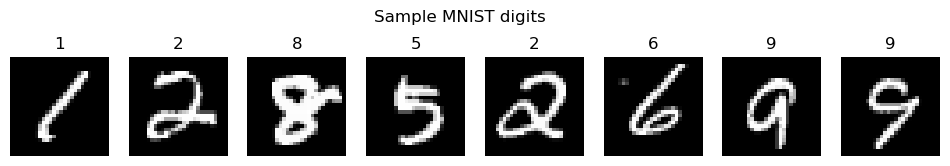

In [114]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(RANDOM_STATE)

transform = transforms.Compose([transforms.ToTensor()])  # pixels in [0, 1]

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

# Quick visual sanity check
sample_imgs, sample_labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(sample_imgs[i][0], cmap="gray")
    ax.set_title(int(sample_labels[i]))
    ax.axis("off")
plt.suptitle("Sample MNIST digits")
plt.show()



<div dir="rtl" lang="fa" style="text-align:right">

<p> یک VAE از دو بخش تشکیل شده:</p>
<ul>
<li><strong>Encoder</strong>: تصویر ورودی رو به پارامترهای یک توزیع نرمال در فضای latent — میانگین <code>μ</code> و لگاریتم واریانس <code>log σ²</code> — نگاشت می‌کنه.</li>
<li><strong>Decoder</strong>: یک نمونه‌ی <code>z</code> که از این توزیع sample شده رو به تصویر بازسازی‌شده تبدیل می‌کنه.</li>
</ul>

<p>نکته‌ی کلیدی VAE، <strong>reparameterization trick</strong> است که اجازه می‌ده گرادیان از میان عملیات sampling عبور کنه (چون sampling مستقیم قابل مشتق‌گیری نیست):</p>

</div>

$$z = \mu + \sigma \odot \epsilon \qquad \epsilon \sim \mathcal{N}(0, I)$$

<div dir="rtl" lang="fa" style="text-align:right">

<p>تابع Loss در VAE از دو جزء تشکیل شده — یکی کیفیت بازسازی تصویر، دیگری منظم بودن فضای latent:</p>

</div>

$$\mathcal{L} = \underbrace{\mathcal{L}_{\text{recon}}}_{\text{شباهت خروجی به ورودی (BCE)}} + \beta \cdot \underbrace{D_{KL}\!\left(q(z|x) \,\|\, p(z)\right)}_{\text{نزدیک بودن توزیع latent به } \mathcal{N}(0,I)}$$

<div dir="rtl" lang="fa" style="text-align:right">

<p>جزء اول مدل رو مجبور می‌کنه تصویر اصلی رو دقیق بازسازی کنه. جزء دوم (KL Divergence) فضای latent رو پیوسته و منظم نگه می‌داره تا بشه ازش نمونه‌ی رندوم کشید.</p>

</div>

In [115]:
LATENT_DIM = 20

class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        # Encoder: 28x28 -> hidden -> (mu, logvar)
        self.enc_fc1 = nn.Linear(28 * 28, 400)
        self.enc_mu = nn.Linear(400, latent_dim)
        self.enc_logvar = nn.Linear(400, latent_dim)

        # Decoder: latent -> hidden -> 28x28
        self.dec_fc1 = nn.Linear(latent_dim, 400)
        self.dec_fc2 = nn.Linear(400, 28 * 28)

    def encode(self, x):
        h = F.relu(self.enc_fc1(x))
        return self.enc_mu(h), self.enc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        return torch.sigmoid(self.dec_fc2(h))

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """Reconstruction loss (BCE) + beta * KL divergence."""
    x_flat = x.view(x.size(0), -1)
    recon_loss = F.binary_cross_entropy(recon_x, x_flat, reduction="sum")
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_div, recon_loss, kl_div


In [117]:
def train_vae(model, loader, optimizer, beta=1.0, epochs=30):
    model.train()
    history = {"total": [], "recon": [], "kl": []}
    for epoch in range(epochs):
        total_loss, total_recon, total_kl = 0, 0, 0
        for x, _ in loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
        n = len(loader.dataset)
        history["total"].append(total_loss / n)
        history["recon"].append(total_recon / n)
        history["kl"].append(total_kl / n)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/n:.2f} | "
              f"Recon: {total_recon/n:.2f} | KL: {total_kl/n:.2f}")
    return history


vae = VAE(latent_dim=LATENT_DIM).to(device)
optimizer_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)

# Keep epochs modest (assignment: avoid excessive training)
vae_history = train_vae(vae, train_loader, optimizer_vae, beta=1.0, epochs=10)


Epoch 1/10 | Loss: 164.79 | Recon: 149.26 | KL: 15.53
Epoch 2/10 | Loss: 121.36 | Recon: 98.77 | KL: 22.59
Epoch 3/10 | Loss: 114.39 | Recon: 90.15 | KL: 24.24
Epoch 4/10 | Loss: 111.56 | Recon: 86.80 | KL: 24.77
Epoch 5/10 | Loss: 109.88 | Recon: 84.87 | KL: 25.01
Epoch 6/10 | Loss: 108.73 | Recon: 83.58 | KL: 25.15
Epoch 7/10 | Loss: 107.94 | Recon: 82.69 | KL: 25.25
Epoch 8/10 | Loss: 107.32 | Recon: 81.95 | KL: 25.37
Epoch 9/10 | Loss: 106.79 | Recon: 81.40 | KL: 25.39
Epoch 10/10 | Loss: 106.34 | Recon: 80.92 | KL: 25.42


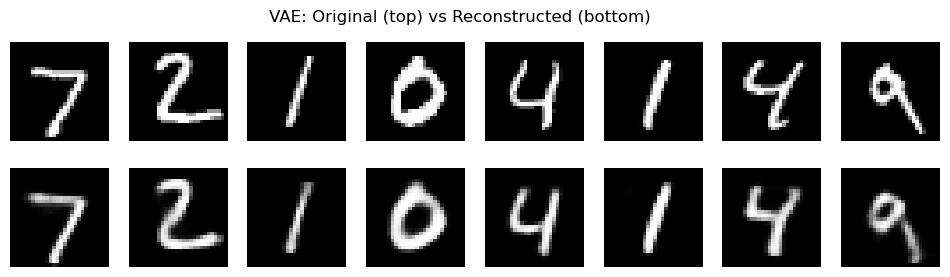

In [21]:
# Visualize reconstructions
vae.eval()
with torch.no_grad():
    x_batch, _ = next(iter(test_loader))
    x_batch = x_batch.to(device)
    recon, mu, logvar = vae(x_batch)
    recon = recon.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x_batch[i][0].cpu(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i][0], cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
plt.suptitle("VAE: Original (top) vs Reconstructed (bottom)")
plt.show()


<div dir="rtl" lang="fa" style="text-align:right">
<p> مدل بعد از چند epoch یاد می‌گیره اکثر ارقام رو با جزئیات قابل قبول بازسازی کنه، ولی تصاویر خروجی VAE معمولاً کمی <strong>تار (blurry)</strong> هستند — این یک محدودیت شناخته‌شده‌ی VAEها است، چون loss از نوع pixel-wise (BCE/MSE) میانگین‌گیری می‌کنه و مدل رو به سمت خروجی‌های «امن» و میانگین سوق می‌ده.</p>
</div>

## 3.B — KL-Divergence Exploration (β-VAE)

<div dir="rtl" lang="fa" style="text-align:right">

<p> جمله‌ی KL-divergence در loss، فضای latent رو مجبور می‌کنه به توزیع نرمال استاندارد نزدیک بمونه (regularization). با ضریب β می‌تونیم اهمیت این جمله رو کنترل کنیم:</p>
<ul>
<li>
<p><strong>β کوچیک (&lt; 1):</strong> تمرکز بیشتر روی reconstruction → کیفیت تصویر بهتر، ولی فضای latent کمتر منظم/disentangled</p>
</li>
<li>
<p><strong>β بزرگ (&gt; 1):</strong> تمرکز بیشتر روی regularization → فضای latent منظم‌تر و <strong>disentangled</strong>‌تر (هر بُعد latent نماینده یک فاکتور مستقل مثل ضخامت خط یا زاویه چرخش میشه)، ولی کیفیت بازسازی معمولاً افت می‌کنه</p>
</li>
</ul>
<p>این دقیقاً ایده‌ی مقاله‌ی β-VAE (Higgins et al., 2017) است.</p>
</div>

In [118]:
betas_to_try = [0.1, 1.0, 4.0]
beta_models = {}
beta_histories = {}

for beta in betas_to_try:
    print(f"\n=== Training VAE with beta = {beta} ===")
    model = VAE(latent_dim=LATENT_DIM).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = train_vae(model, train_loader, opt, beta=beta, epochs=6)  # fewer epochs, just for comparison
    beta_models[beta] = model
    beta_histories[beta] = hist



=== Training VAE with beta = 0.1 ===
Epoch 1/6 | Loss: 141.48 | Recon: 136.29 | KL: 51.89
Epoch 2/6 | Loss: 90.80 | Recon: 84.60 | KL: 62.05
Epoch 3/6 | Loss: 84.08 | Recon: 78.13 | KL: 59.44
Epoch 4/6 | Loss: 80.96 | Recon: 75.20 | KL: 57.60
Epoch 5/6 | Loss: 79.01 | Recon: 73.36 | KL: 56.52
Epoch 6/6 | Loss: 77.67 | Recon: 72.09 | KL: 55.80

=== Training VAE with beta = 1.0 ===
Epoch 1/6 | Loss: 164.85 | Recon: 149.39 | KL: 15.46
Epoch 2/6 | Loss: 121.37 | Recon: 98.90 | KL: 22.47
Epoch 3/6 | Loss: 114.51 | Recon: 90.56 | KL: 23.95
Epoch 4/6 | Loss: 111.47 | Recon: 86.97 | KL: 24.51
Epoch 5/6 | Loss: 109.70 | Recon: 84.92 | KL: 24.78
Epoch 6/6 | Loss: 108.52 | Recon: 83.58 | KL: 24.93

=== Training VAE with beta = 4.0 ===
Epoch 1/6 | Loss: 193.36 | Recon: 175.08 | KL: 4.57
Epoch 2/6 | Loss: 164.36 | Recon: 134.20 | KL: 7.54
Epoch 3/6 | Loss: 158.84 | Recon: 125.71 | KL: 8.28
Epoch 4/6 | Loss: 156.26 | Recon: 121.50 | KL: 8.69
Epoch 5/6 | Loss: 154.58 | Recon: 119.00 | KL: 8.89
Epoch

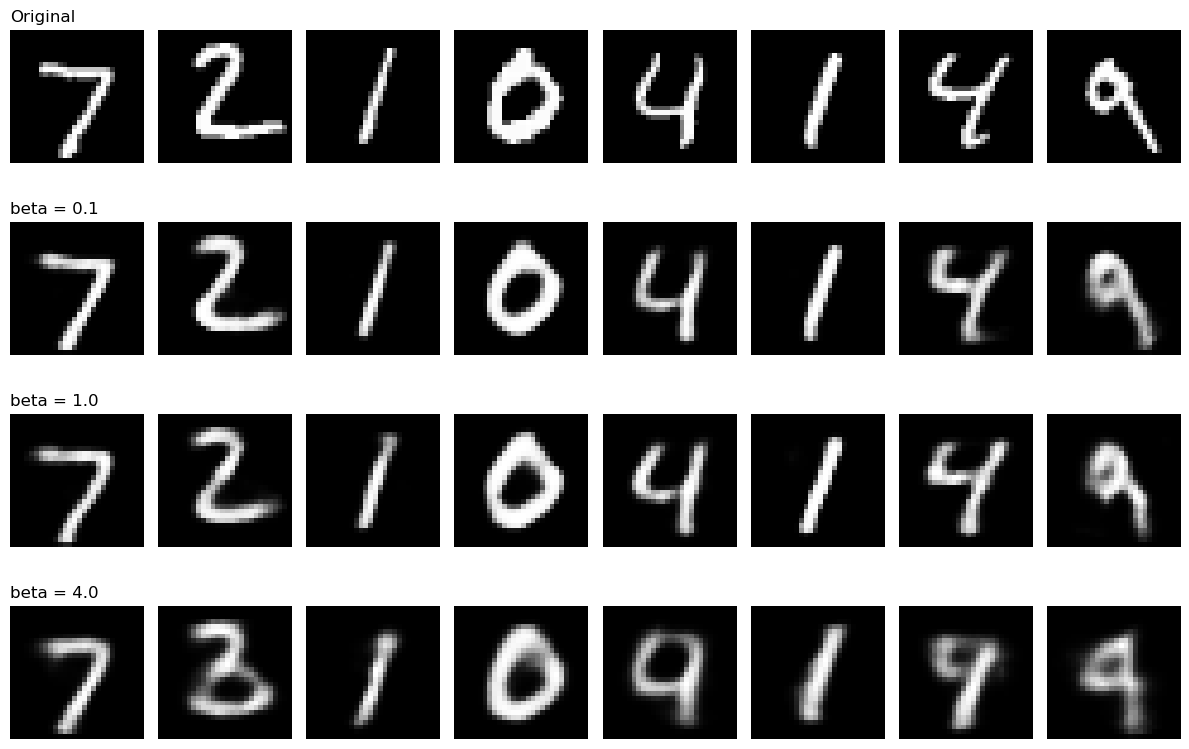

,beta,final_recon_loss,final_kl_loss
0,0.1,72.093499,55.795223
1,1.0,83.582261,24.933725
2,4.0,117.209061,9.073427


In [119]:
# Compare reconstruction quality across betas
x_batch, _ = next(iter(test_loader))
x_batch = x_batch.to(device)

fig, axes = plt.subplots(len(betas_to_try) + 1, 8, figsize=(12, 2 * (len(betas_to_try) + 1)))
for i in range(8):
    axes[0, i].imshow(x_batch[i][0].cpu(), cmap="gray")
    axes[0, i].axis("off")
axes[0, 0].set_title("Original", loc="left")

for row, beta in enumerate(betas_to_try, start=1):
    model = beta_models[beta]
    model.eval()
    with torch.no_grad():
        recon, mu, logvar = model(x_batch)
        recon = recon.view(-1, 1, 28, 28).cpu()
    for i in range(8):
        axes[row, i].imshow(recon[i][0], cmap="gray")
        axes[row, i].axis("off")
    axes[row, 0].set_title(f"beta = {beta}", loc="left")

plt.tight_layout()
plt.show()

# Compare final KL and reconstruction loss values
comparison = pd.DataFrame({
    "beta": betas_to_try,
    "final_recon_loss": [beta_histories[b]["recon"][-1] for b in betas_to_try],
    "final_kl_loss": [beta_histories[b]["kl"][-1] for b in betas_to_try],
})
comparison


<div dir="rtl" lang="fa" style="text-align:right">

<p> با افزایش β یک trade-off واضح می‌بینیم:</p>

<ul>
<li><strong>KL loss کاهش پیدا می‌کنه</strong> — مدل بیشتر تلاش می‌کنه فضای latent رو به نرمال استاندارد نزدیک کنه، پس توزیع منظم‌تر و disentangled‌تر میشه.</li>
<li><strong>Reconstruction loss افزایش پیدا می‌کنه</strong> — تصاویر بازسازی‌شده تارتر و کم‌جزئیات‌تر میشن، چون مدل مجبوره اطلاعات بیشتری رو فشرده کنه.</li>
</ul>

<p>به عبارت دیگه: β کوچیک‌تر → تصویر شارپ‌تر ولی فضای latent درهم‌تر. β بزرگ‌تر → فضای latent منظم‌تر ولی کیفیت بصری پایین‌تر. این دقیقاً ایده‌ی اصلی مقاله‌ی β-VAE است.</p>

</div>

## 3.C — Latent Space Sampling & Interpolation

<div dir="rtl" lang="fa" style="text-align:right">

<p> یکی از ویژگی‌های کلیدی VAE اینه که فضای latent <strong>پیوسته و smooth</strong> است (به لطف جمله‌ی KL که این فضا رو منظم می‌کنه). بنابراین می‌تونیم:</p>
<ol>
<li>
<p>بین دو نمونه‌ی واقعی، در فضای latent <strong>خطی interpolate</strong> کنیم و ببینیم گذار بین دو رقم چطور اتفاق می‌افته</p>
</li>
<li>
<p>مستقیماً از فضای latent (نرمال استاندارد) <strong>نمونه‌ی رندوم</strong> بگیریم و رقم جدید تولید کنیم</p>
</li>
</ol>
</div>

In [2]:
vae.eval()

# ---- (1) Interpolation between two real digits ----
x_batch, y_batch = next(iter(test_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    mu, logvar = vae.encode(x_batch.view(x_batch.size(0), -1))

idx_a, idx_b = 0, 1  # pick two different digits
z_a, z_b = mu[idx_a], mu[idx_b]
print(f"Interpolating between digit '{y_batch[idx_a].item()}' and digit '{y_batch[idx_b].item()}'")

n_steps = 10
alphas = np.linspace(0, 1, n_steps)
interpolated_imgs = []

with torch.no_grad():
    for alpha in alphas:
        z_interp = (1 - alpha) * z_a + alpha * z_b
        img = vae.decode(z_interp.unsqueeze(0)).view(28, 28).cpu()
        interpolated_imgs.append(img)

fig, axes = plt.subplots(1, n_steps, figsize=(15, 2))
for i, img in enumerate(interpolated_imgs):
    axes[i].imshow(img, cmap="gray")
    axes[i].axis("off")
plt.suptitle("Latent space interpolation between two digits")
plt.show()

# ---- (2) Random sampling directly from the prior N(0, I) ----
with torch.no_grad():
    z_random = torch.randn(16, LATENT_DIM).to(device)
    generated = vae.decode(z_random).view(-1, 1, 28, 28).cpu()

grid = vutils.make_grid(generated, nrow=8, padding=2)
plt.figure(figsize=(10, 3))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Randomly generated digits (sampled from N(0, I))")
plt.show()


NameError: name 'vae' is not defined

<div dir="rtl" lang="fa" style="text-align:right">
<p> گذار بین دو رقم در interpolation معمولاً <strong>smooth و معنادار</strong> است (نه یک پرش ناگهانی)، که نشون می‌ده VAE یک فضای latent پیوسته و ساختاریافته یاد گرفته. نمونه‌های رندوم گرفته‌شده مستقیماً از 

$\mathcal{N}(0, I)$ هم معمولاً شبیه ارقام واقعی هستند ولی به دلیل ماهیت VAE، کمی محو و تار به نظر می‌رسند.</p>
</div>

# Part 4 — Generative Adversarial Networks (GAN)

<div dir="rtl" lang="fa" style="text-align:right">
<hr />

<p>برخلاف VAE که یک مدل احتمالاتی صریح با loss از نوع likelihood است، GAN بر پایه‌ی یک <strong>بازی دو نفره (min-max game)</strong> بین دو شبکه است:</p>
<ul>
<li><strong>Generator (G):</strong> نویز رندوم <code>z</code> رو به تصویر جعلی تبدیل می‌کنه — هدفش فریب دادن Discriminator است.</li>
<li><strong>Discriminator (D):</strong> سعی می‌کنه بین تصویر واقعی و تصویر جعلی تمایز قائل بشه.</li>
</ul>

<p>هر دو شبکه به صورت هم‌زمان و رقابتی آموزش می‌بینن. هدف کلی بازی:</p>

</div>

$$\min_{G} \max_{D}\; \mathbb{E}_{x \sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

</div>

<div dir="rtl" lang="fa" style="text-align:right">
<p>به زبان ساده: D می‌خواد تصاویر واقعی رو درست تشخیص بده (امتیاز بالا) و G می‌خواد تصاویری بسازه که D فریب بخوره (امتیاز پایین). وقتی این دو به تعادل نش برسن، G یاد گرفته توزیع داده‌ی واقعی رو شبیه‌سازی کنه.</p>
</div>

In [121]:
LATENT_DIM_GAN = 100

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM_GAN, img_dim=28 * 28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()  # output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self, img_dim=28 * 28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()  # probability of being real
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


<div dir="rtl" lang="fa" style="text-align:right">
<p> از یک GAN ساده fully-connected (نه DCGAN) استفاده می‌کنیم چون MNIST ابعاد کوچیکی داره (28×28) و هدف اصلی assignment، فهم مکانیزم آموزش adversarial است، نه رسیدن به state-of-the-art. خروجی Generator با <code>Tanh</code> در بازه‌ی <code>[-1, 1]</code> است، پس تصاویر واقعی رو هم باید normalize کنیم.</p>
</div>

In [122]:
# Rebuild dataloader with normalization to [-1, 1] to match Generator's Tanh output
transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset_gan = datasets.MNIST(root="./data", train=True, download=True, transform=transform_gan)
train_loader_gan = DataLoader(train_dataset_gan, batch_size=128, shuffle=True, num_workers=2)

generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
opt_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, LATENT_DIM_GAN, device=device)  # for consistent visualization across epochs


In [124]:
def train_gan(generator, discriminator, loader, epochs=10):
    g_losses, d_losses = [], []
    snapshots = {}

    for epoch in range(epochs):
        epoch_g_loss, epoch_d_loss = 0, 0
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # ---- Train Discriminator ----
            opt_d.zero_grad()
            d_real = discriminator(real_imgs)
            loss_d_real = criterion(d_real, real_labels)

            z = torch.randn(batch_size, LATENT_DIM_GAN, device=device)
            fake_imgs = generator(z)
            d_fake = discriminator(fake_imgs.detach())  # detach so G is not updated here
            loss_d_fake = criterion(d_fake, fake_labels)

            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            opt_d.step()

            # ---- Train Generator ----
            opt_g.zero_grad()
            d_fake_for_g = discriminator(fake_imgs)
            # Generator wants discriminator to classify fakes as real
            loss_g = criterion(d_fake_for_g, real_labels)
            loss_g.backward()
            opt_g.step()

            epoch_g_loss += loss_g.item()
            epoch_d_loss += loss_d.item()

        g_losses.append(epoch_g_loss / len(loader))
        d_losses.append(epoch_d_loss / len(loader))

        print(f"Epoch {epoch+1}/{epochs} | D loss: {d_losses[-1]:.4f} | G loss: {g_losses[-1]:.4f}")

        # Save a snapshot of generated images every few epochs for visualization
        if (epoch + 1) % 5 == 0 or epoch == 0:
            with torch.no_grad():
                generator.eval()
                snap = generator(fixed_noise).cpu()
                generator.train()
            snapshots[epoch + 1] = snap

    return g_losses, d_losses, snapshots


g_losses, d_losses, snapshots = train_gan(generator, discriminator, train_loader_gan, epochs=10)


Epoch 1/10 | D loss: 0.4316 | G loss: 2.7687
Epoch 2/10 | D loss: 0.4368 | G loss: 2.6144
Epoch 3/10 | D loss: 0.5549 | G loss: 2.3378
Epoch 4/10 | D loss: 0.6018 | G loss: 2.2063
Epoch 5/10 | D loss: 0.6958 | G loss: 2.0525
Epoch 6/10 | D loss: 0.7162 | G loss: 1.9889
Epoch 7/10 | D loss: 0.7985 | G loss: 1.7654
Epoch 8/10 | D loss: 0.8537 | G loss: 1.6520
Epoch 9/10 | D loss: 0.8858 | G loss: 1.5873
Epoch 10/10 | D loss: 0.9172 | G loss: 1.5292


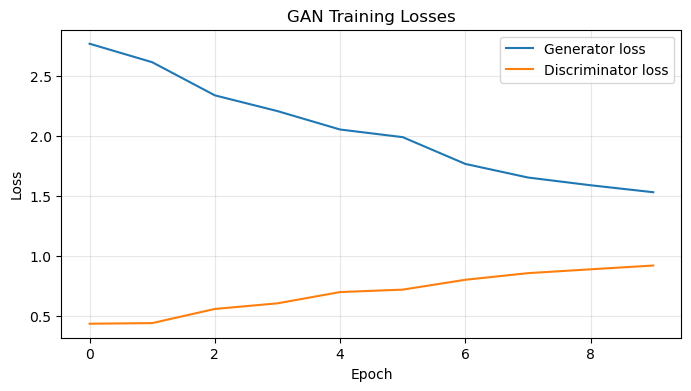

In [125]:
# Plot generator / discriminator losses
plt.figure(figsize=(8, 4))
plt.plot(g_losses, label="Generator loss")
plt.plot(d_losses, label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


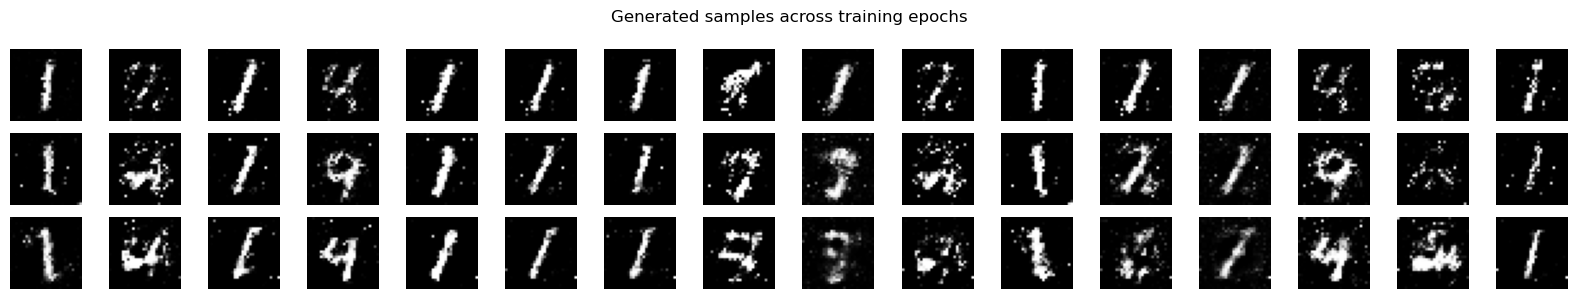

In [126]:
# Visualize generated samples across training epochs
epochs_to_show = sorted(snapshots.keys())
fig, axes = plt.subplots(len(epochs_to_show), 16, figsize=(16, len(epochs_to_show)))

for row, ep in enumerate(epochs_to_show):
    imgs = (snapshots[ep] + 1) / 2  # de-normalize from [-1,1] to [0,1]
    for i in range(16):
        ax = axes[row, i] if len(epochs_to_show) > 1 else axes[i]
        ax.imshow(imgs[i][0], cmap="gray")
        ax.axis("off")
    (axes[row, 0] if len(epochs_to_show) > 1 else axes[0]).set_ylabel(f"Epoch {ep}", fontsize=9)

plt.suptitle("Generated samples across training epochs")
plt.tight_layout()
plt.show()


<div dir="rtl" lang="fa" style="text-align:right">
<p>در epochهای اول، خروجی Generator بیشتر شبیه نویز بی‌شکل است. با پیشرفت آموزش، تدریجاً اشکال شبیه رقم واقعی ظاهر می‌شن. بر خلاف VAE، تصاویر GAN معمولاً <strong>شارپ‌تر و واقعی‌تر</strong> به نظر می‌رسن (چون Generator صرفاً باید Discriminator رو فریب بده، نه یک reconstruction loss پیکسل‌به‌پیکسل رو کمینه کنه) — ولی آموزش GAN معمولاً <strong>ناپایدارتر</strong> است (نوسان loss ها) در مقایسه با VAE.</p>
</div>

## Discussion Question — Mode Collapse در GAN

<div dir="rtl" lang="fa" style="text-align:right">

<p><strong>چرا GAN ممکنه دچار mode collapse بشه؟</strong></p>
<p>Mode collapse زمانی رخ می‌ده که Generator به جای یادگیری <strong>کل توزیع داده</strong> (که شامل چندین "mode" یا خوشه است — مثلاً هر ۱۰ رقم در MNIST یک mode مجزا هستند)، یاد بگیره فقط روی یک یا چند mode محدود تمرکز کنه و همون نمونه‌ها (یا نمونه‌های خیلی شبیه به هم) رو مدام تولید کنه. علتش:</p>
<ol>
<li>
<p><strong>بازی min-max غیرمتقارن:</strong> Generator فقط باید Discriminator رو در <strong>هر لحظه</strong> فریب بده، نه لزوماً کل فضای داده رو پوشش بده. اگه یک mode خاص (مثلاً فقط رقم "۱") بتونه Discriminator رو به طور مداوم فریب بده، Generator انگیزه‌ای نداره ریسک کنه و modeهای دیگه رو exploration کنه.</p>
</li>
<li>
<p><strong>عدم وجود مکانیزم صریح coverage:</strong> برخلاف مدل‌های likelihood-based (مثل VAE) که مستقیماً سعی می‌کنن <code>log p(x)</code> رو روی <em>کل</em> دیتاست بیشینه کنن، GAN هیچ جمله‌ی صریحی برای "پوشش دادن تمام modeها" نداره.</p>
</li>
<li>
<p><strong>Discriminator ضعیف یا overfit:</strong> اگه Discriminator خیلی سریع "شکست بخوره" یا gradient ضعیفی بده، Generator فیدبک کافی برای بهبود تنوع دریافت نمی‌کنه.</p>
</li>
</ol>
<p><strong>چرا هیچ تضمین رسمی وجود نداره که mode collapse رخ بده (یا رخ نده)؟</strong></p>
<p>از نظر تئوری، اگه هر دو شبکه (G و D) به ظرفیت بی‌نهایت برسن و آموزش به <strong>نقطه‌ی تعادل نش (Nash Equilibrium)</strong> همگرا بشه، می‌شه ثابت کرد که توزیع Generator دقیقاً برابر توزیع داده‌ی واقعی می‌شه (طبق اثبات اصلی Goodfellow et al., 2014). اما این اثبات چند فرض قوی داره که در عمل صادق نیستند:</p>
<ul>
<li>
<p>بهینه‌سازی gradient descent (نه بهینه‌سازی سراسری) استفاده می‌شه، که تضمین همگرایی به Nash Equilibrium رو نمی‌ده (چون فضای loss غیرمحدب/non-convex و بازی non-cooperative است).</p>
</li>
<li>
<p>شبکه‌ها ظرفیت محدود دارن (نه بی‌نهایت).</p>
</li>
<li>
<p>آموزش به صورت <strong>متناوب</strong> (نه هم‌زمان کامل) بین G و D انجام می‌شه، که می‌تونه دینامیک‌های ناپایدار (نوسان، cycling) ایجاد کنه.</p>
</li>
</ul>
<p>به همین دلیل، mode collapse یک <strong>پدیده‌ی تجربی شناخته‌شده</strong> است، نه یک نتیجه‌ی قطعی از تئوری — ممکنه در یک run رخ بده و در run دیگه (با seed متفاوت یا معماری/hyperparameter کمی متفاوت) رخ نده. تکنیک‌هایی مثل <strong>minibatch discrimination</strong>, <strong>unrolled GANs</strong>, <strong>Wasserstein GAN (WGAN)</strong>, یا <strong>spectral normalization</strong> برای کاهش (نه حذف قطعی) این ریسک پیشنهاد شدن.</p>
</div>

# Part 5 — Diffusion Models

<div dir="rtl" lang="fa" style="text-align:right">
<hr />

<p> مدل‌های Diffusion (مثل DDPM) در سال‌های اخیر state-of-the-art مدل‌های تولیدی تصویر شدن (پایه‌ی مدل‌هایی مثل Stable Diffusion و DALL-E 2). ایده‌ی اصلی برخلاف GAN/VAE اینه که به جای یادگیری مستقیم نگاشت از نویز به تصویر، مدل یاد می‌گیره <strong>به تدریج نویز رو حذف کنه</strong> (denoising) طی چندین مرحله.</p>
<p>در این بخش:</p>
<ul>
<li>
<p><strong>5.A</strong> یک DDPM ساده روی MNIST پیاده و آموزش می‌دیم</p>
</li>
<li>
<p><strong>5.B</strong> دو noise schedule (خطی و کسینوسی) رو مقایسه می‌کنیم</p>
</li>
<li>
<p><strong>5.C </strong>و Diffusion رو با GAN (از Part 4) از نظر کیفیت، تنوع، و پایداری آموزش مقایسه می‌کنیم</p>
</li>
</ul>
</div>

## 5.0 پیش‌زمینه‌ی ریاضی DDPM

<div dir="rtl" lang="fa" style="text-align:right">
<p><strong>Forward process (اضافه کردن نویز):</strong> طی $T$ گام، نویز گاوسی به تدریج به تصویر اضافه می‌شه تا به نویز خالص تبدیل بشه:</p>
</div>

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(x_t;\; \sqrt{1-\beta_t}\, x_{t-1},\; \beta_t I\right)$$

<div dir="rtl" lang="fa" style="text-align:right">
<p>با یک trick ریاضی می‌شه مستقیماً $x_t$ رو از $x_0$ بدون شبیه‌سازی گام‌های میانی حساب کرد:</p>
</div>

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\,\epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$

<div dir="rtl" lang="fa" style="text-align:right">
<p>که در آن $\\alpha_t = 1 - \\beta_t$ و $\\bar{\\alpha}_t = \\prod_{s=1}^{t} \\alpha_s$.</p>
<p><strong>Reverse process:</strong> یک U-Net آموزش می‌بینه که نویز اضافه‌شده را در هر گام پیش‌بینی کنه و تصویر رو گام‌به‌گام denoise کنه.</p>
<p><strong>Loss ساده‌شده (Ho et al., 2020):</strong></p>
</div>

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t,\, x_0,\, \epsilon} \left[\, \|\epsilon - \epsilon_\theta(x_t, t)\|^2 \,\right]$$

In [127]:
import math

class SinusoidalTimeEmbedding(nn.Module):
    """Encode the diffusion timestep t into a vector, similar to positional
    encoding in Transformers, so the model knows 'how noisy' the input currently is."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)


class SimpleUNet(nn.Module):
    """A lightweight U-Net-style noise predictor for 28x28 MNIST images.
    Kept small on purpose to keep training time reasonable, per assignment guidance."""
    def __init__(self, time_emb_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU(),
        )

        # Downsampling
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1, stride=2)   # 28 -> 14
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1, stride=2)  # 14 -> 7

        self.time_proj1 = nn.Linear(time_emb_dim, 32)
        self.time_proj2 = nn.Linear(time_emb_dim, 64)
        self.time_proj3 = nn.Linear(time_emb_dim, 128)

        # Upsampling
        self.up1 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)  # 7 -> 14
        self.up2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)   # 14 -> 28
        self.out_conv = nn.Conv2d(32, 1, 3, padding=1)

        self.act = nn.ReLU()

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        h1 = self.act(self.conv1(x) + self.time_proj1(t_emb)[:, :, None, None])
        h2 = self.act(self.conv2(h1) + self.time_proj2(t_emb)[:, :, None, None])
        h3 = self.act(self.conv3(h2) + self.time_proj3(t_emb)[:, :, None, None])

        u1 = self.act(self.up1(h3) + h2)
        u2 = self.act(self.up2(u1) + h1)
        out = self.out_conv(u2)
        return out


## 5.A — Denoising Diffusion Model (DDPM)

<div dir="rtl" lang="fa" style="text-align:right">

<p> حالا forward process (اضافه کردن نویز طبق schedule) و training loop (پیش‌بینی نویز با loss از نوع MSE) رو پیاده می‌کنیم.</p>
</div>

In [128]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)


class DiffusionModel:
    def __init__(self, model, T=200, schedule="linear", device=device):
        self.model = model.to(device)
        self.T = T
        self.device = device

        if schedule == "linear":
            self.betas = linear_beta_schedule(T).to(device)
        elif schedule == "cosine":
            self.betas = cosine_beta_schedule(T).to(device)  # defined in 5.B below
        else:
            raise ValueError("Unknown schedule")

        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise=None):
        """Forward process: directly sample x_t from x_0 at timestep t."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_1m_ac = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x0 + sqrt_1m_ac * noise, noise

    def train_step(self, x0, optimizer):
        batch_size = x0.size(0)
        t = torch.randint(0, self.T, (batch_size,), device=self.device).long()
        x_t, noise = self.q_sample(x0, t)
        predicted_noise = self.model(x_t, t)
        loss = F.mse_loss(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        return loss.item()

    @torch.no_grad()
    def sample(self, n_samples, img_size=28):
        """Reverse process: start from pure noise and iteratively denoise."""
        self.model.eval()
        x = torch.randn(n_samples, 1, img_size, img_size, device=self.device)

        for t_step in reversed(range(self.T)):
            t = torch.full((n_samples,), t_step, device=self.device, dtype=torch.long)
            predicted_noise = self.model(x, t)

            alpha_t = self.alphas[t_step]
            alpha_cumprod_t = self.alphas_cumprod[t_step]
            beta_t = self.betas[t_step]

            if t_step > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = (1 / torch.sqrt(alpha_t)) * (
                x - (beta_t / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise
            ) + torch.sqrt(beta_t) * noise

        self.model.train()
        return x


In [129]:
# Train a lightweight DDPM (small T and few epochs to keep runtime reasonable)
unet = SimpleUNet()
diffusion = DiffusionModel(unet, T=200, schedule="linear")
opt_diff = torch.optim.Adam(diffusion.model.parameters(), lr=2e-4)

EPOCHS_DIFFUSION = 5  # kept small on purpose; increase if you have GPU time available

loss_history_diff = []
for epoch in range(EPOCHS_DIFFUSION):
    epoch_loss = 0
    for x0, _ in train_loader_gan:  # reuse the [-1, 1]-normalized MNIST loader from Part 4
        x0 = x0.to(device)
        loss = diffusion.train_step(x0, opt_diff)
        epoch_loss += loss
    avg_loss = epoch_loss / len(train_loader_gan)
    loss_history_diff.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS_DIFFUSION} | MSE loss: {avg_loss:.4f}")


Epoch 1/5 | MSE loss: 0.2948
Epoch 2/5 | MSE loss: 0.1339
Epoch 3/5 | MSE loss: 0.1106
Epoch 4/5 | MSE loss: 0.0988
Epoch 5/5 | MSE loss: 0.0920


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16703713..1.2708825].


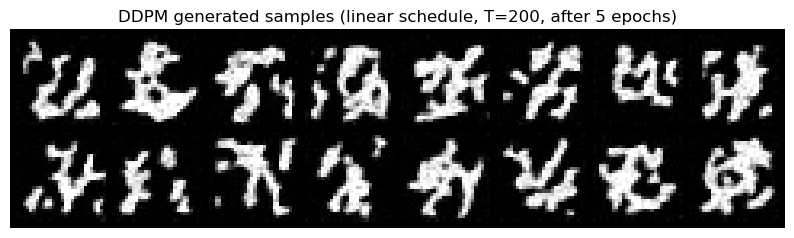

In [130]:
# Generate samples from the trained DDPM
generated_diff = diffusion.sample(n_samples=16)
generated_diff = (generated_diff.cpu() + 1) / 2  # de-normalize to [0, 1]

grid = vutils.make_grid(generated_diff, nrow=8, padding=2)
plt.figure(figsize=(10, 3))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title(f"DDPM generated samples (linear schedule, T={diffusion.T}, after {EPOCHS_DIFFUSION} epochs)")
plt.show()


<div dir="rtl" lang="fa" style="text-align:right">
<p> حتی با یک U-Net کوچیک و تعداد گام (T) و epoch محدود، DDPM شروع به تولید اشکالی می‌کنه که به رقم شباهت دارن. برخلاف GAN که Generator مستقیماً از نویز به تصویر می‌پره، اینجا denoising به صورت <strong>تدریجی و گام‌به‌گام</strong> انجام می‌شه که پایدارتر ولی <strong>کندتر</strong> (به دلیل نیاز به T پاس forward برای هر نمونه در inference) است.</p>
</div>

new_c71 = """## 5.B — Noise Schedule Experimentation (Linear vs Cosine)

<div dir="rtl" lang="fa" style="text-align:right">

<p> نحوه‌ی افزایش نویز طی زمان (<code>beta_t</code>) روی کیفیت نهایی مدل تأثیر می‌ذاره:</p>
<ul>
<li><strong>Linear schedule:</strong> نویز به صورت خطی از <code>beta_start</code> به <code>beta_end</code> افزایش پیدا می‌کنه (schedule اصلی مقاله‌ی DDPM). مشکل: در گام‌های پایانی خیلی سریع نویز اضافه می‌شه و اطلاعات تصویر زود از بین می‌ره.</li>
<li><strong>Cosine schedule</strong> (Nichol &amp; Dhariwal, 2021): بر پایه‌ی تابع کسینوس طراحی شده تا نویز <strong>آرام‌تر و یکنواخت‌تر</strong> اضافه بشه، مخصوصاً در ابتدای فرایند — که معمولاً کیفیت نمونه‌های نهایی رو بهبود می‌ده.</li>
</ul>

<p>فرمول cosine schedule:</p>

</div>

$$\bar{\alpha}_t = \frac{f(t)}{f(0)}, \qquad f(t) = \cos\!\left(\frac{t/T + s}{1 + s} \cdot \frac{\pi}{2}\right)^{\!2}$$

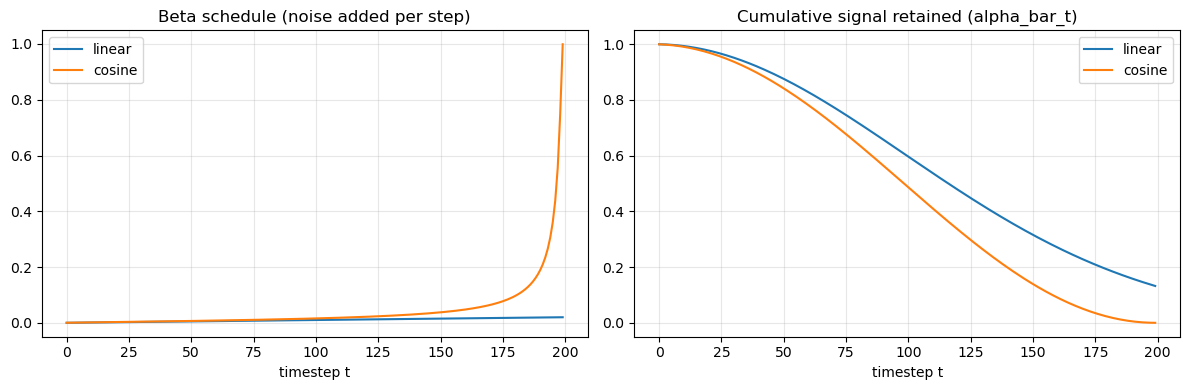

In [131]:
def cosine_beta_schedule(T, s=0.008):
    """Cosine schedule from 'Improved Denoising Diffusion Probabilistic Models' (Nichol & Dhariwal, 2021)."""
    steps = T + 1
    t = torch.linspace(0, T, steps) / T
    f_t = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
    alphas_cumprod = f_t / f_t[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 1e-4, 0.999)


# Visualize the two schedules
T_compare = 200
linear_betas = linear_beta_schedule(T_compare)
cosine_betas = cosine_beta_schedule(T_compare)

linear_ac = torch.cumprod(1 - linear_betas, dim=0)
cosine_ac = torch.cumprod(1 - cosine_betas, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(linear_betas, label="linear")
axes[0].plot(cosine_betas, label="cosine")
axes[0].set_title("Beta schedule (noise added per step)")
axes[0].set_xlabel("timestep t")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(linear_ac, label="linear")
axes[1].plot(cosine_ac, label="cosine")
axes[1].set_title("Cumulative signal retained (alpha_bar_t)")
axes[1].set_xlabel("timestep t")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [132]:
# Train a second DDPM using the cosine schedule for direct comparison
unet_cosine = SimpleUNet()
diffusion_cosine = DiffusionModel(unet_cosine, T=200, schedule="cosine")
opt_diff_cosine = torch.optim.Adam(diffusion_cosine.model.parameters(), lr=2e-4)

loss_history_cosine = []
for epoch in range(EPOCHS_DIFFUSION):
    epoch_loss = 0
    for x0, _ in train_loader_gan:
        x0 = x0.to(device)
        loss = diffusion_cosine.train_step(x0, opt_diff_cosine)
        epoch_loss += loss
    avg_loss = epoch_loss / len(train_loader_gan)
    loss_history_cosine.append(avg_loss)
    print(f"[cosine] Epoch {epoch+1}/{EPOCHS_DIFFUSION} | MSE loss: {avg_loss:.4f}")


[cosine] Epoch 1/5 | MSE loss: 0.2460
[cosine] Epoch 2/5 | MSE loss: 0.1123
[cosine] Epoch 3/5 | MSE loss: 0.0937
[cosine] Epoch 4/5 | MSE loss: 0.0846
[cosine] Epoch 5/5 | MSE loss: 0.0793


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16703713..1.2708825].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13510835..1.349153].


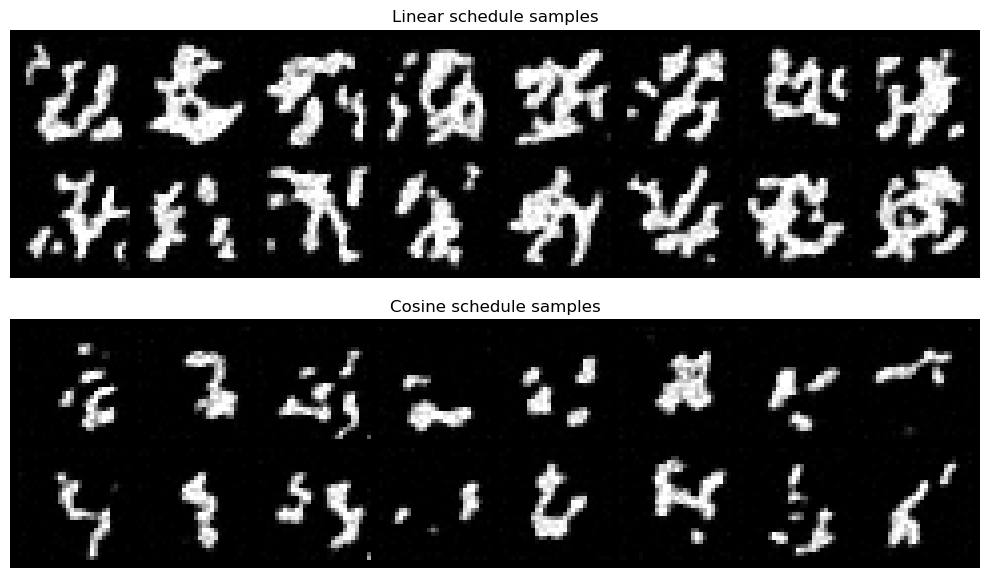

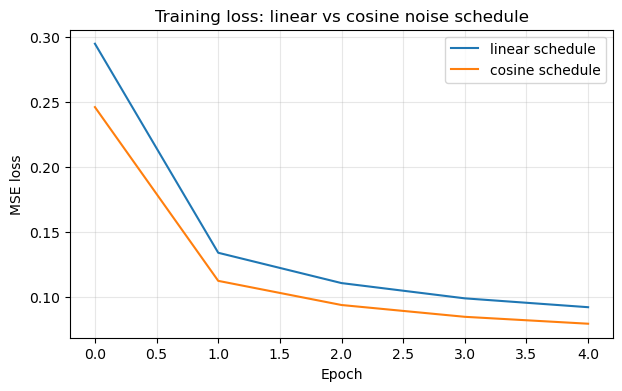

In [133]:
# Compare generated samples: linear vs cosine schedule
generated_cosine = diffusion_cosine.sample(n_samples=16)
generated_cosine = (generated_cosine.cpu() + 1) / 2

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
grid_linear = vutils.make_grid(generated_diff, nrow=8, padding=2)
grid_cosine = vutils.make_grid(generated_cosine, nrow=8, padding=2)

axes[0].imshow(grid_linear.permute(1, 2, 0), cmap="gray")
axes[0].set_title("Linear schedule samples")
axes[0].axis("off")

axes[1].imshow(grid_cosine.permute(1, 2, 0), cmap="gray")
axes[1].set_title("Cosine schedule samples")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Compare training loss curves
plt.figure(figsize=(7, 4))
plt.plot(loss_history_diff, label="linear schedule")
plt.plot(loss_history_cosine, label="cosine schedule")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss: linear vs cosine noise schedule")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


<div dir="rtl" lang="fa" style="text-align:right">
<p>با تعداد epoch محدود (که برای این تمرین عمداً کم نگه داشتیم)، تفاوت بین دو schedule ممکنه چشمگیر نباشه، ولی از نظر تئوری و در training طولانی‌تر، schedule کسینوسی معمولاً باعث می‌شه اطلاعات تصویر <strong>آرام‌تر</strong> از بین بره (مخصوصاً نزدیک $t=0$)، که به مدل فرصت بهتری برای یادگیری جزئیات ظریف می‌ده و در نتیجه کیفیت نمونه‌های نهایی رو بهبود می‌بخشه.</p>
</div>

## 5.C — Diffusion vs. GAN Comparison

<div dir="rtl" lang="fa" style="text-align:right">

<p>حالا که هم GAN (Part 4) و هم Diffusion Model (Part 5.A/B) رو آموزش دادیم، مقایسه‌ای کیفی و کمی بین این دو خانواده از مدل‌های تولیدی انجام می‌دیم.</p>
</div>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16703713..1.2708825].


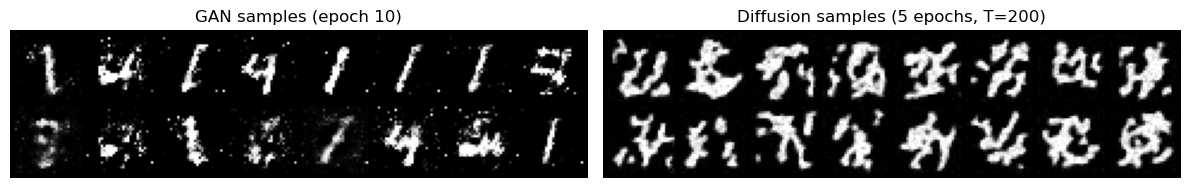

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gan_final = (snapshots[max(snapshots.keys())] + 1) / 2
grid_gan = vutils.make_grid(gan_final, nrow=8, padding=2)
axes[0].imshow(grid_gan.permute(1, 2, 0), cmap="gray")
axes[0].set_title(f"GAN samples (epoch {max(snapshots.keys())})")
axes[0].axis("off")

axes[1].imshow(grid_linear.permute(1, 2, 0), cmap="gray")
axes[1].set_title(f"Diffusion samples ({EPOCHS_DIFFUSION} epochs, T={diffusion.T})")
axes[1].axis("off")

plt.tight_layout()
plt.show()


<div dir="rtl" lang="fa" style="text-align:right">
<p><strong>جدول مقایسه‌ی کیفی:</strong></p>
<table><thead><tr><th>معیار</th><th>GAN</th><th>Diffusion Model</th></tr></thead><tbody><tr><td><strong>کیفیت خروجی </strong></td><td>معمولاً شارپ و واضح، ولی می‌تونه در آموزش‌های ناقص artifact داشته باشه</td><td>معمولاً smooth و باکیفیت، حتی با آموزش کوتاه‌تر artifact بصری کمتری داره</td></tr><tr><td><strong>تنوع </strong></td><td>مستعد <strong>mode collapse</strong> — ممکنه فقط زیرمجموعه‌ای از modeهای داده رو پوشش بده</td><td>پوشش بهتر توزیع داده به دلیل ماهیت likelihood-based بودن فرایند، تنوع بیشتر</td></tr><tr><td><strong>پایداری آموزش </strong></td><td>ناپایدار — نیاز به تعادل دقیق بین G و D؛ نوسان loss رایج است</td><td>پایدارتر — یک هدف ساده (MSE روی پیش‌بینی نویز) و بدون بازی adversarial</td></tr><tr><td><strong>سرعت </strong></td><td>بسیار سریع </td><td>کند — نیاز به T گام forward pass متوالی برای تولید هر نمونه</td></tr><tr><td><strong>سرعت/هزینه </strong></td><td>نسبتاً سریع</td><td>معمولاً کندتر (به دلیل نیاز به دیدن تمام سطوح نویز t=0...T)</td></tr></tbody></table>

<p>به طور کلی diffusion modelها به دلیل پایداری آموزش و کیفیت/تنوع بالاتر، به تدریج جایگزین GAN به عنوان state-of-the-art مدل‌های تولید تصویر شدن (مثلاً در Stable Diffusion، Imagen، DALL-E 2)، اما هزینه‌ی محاسباتی inference بسیار بالاتری دارن؛ به همین دلیل تحقیقات زیادی روی تسریع sampling (مثل DDIM، Distillation) در جریان است. GAN هنوز هم برای کاربردهایی که به <strong>inference بلادرنگ </strong> نیاز دارن (super-resolution) جذابیت خودش رو حفظ کرده.</p>
</div>

# Part 6 — Explainable AI (XAI)


## 6.0 آموزش یک CNN classifier 
<div dir="rtl" lang="fa" style="text-align:right">

<p>برای اجرای Grad-CAM و سایر تکنیک‌های XAI، اول باید یک مدل classification آموزش‌دیده داشته باشیم که بخوایم رفتارش رو تفسیر کنیم.</p>
</div>

In [135]:
class SimpleCNN(nn.Module):
    """A standard small CNN for MNIST classification (10 classes).
    Mirrors a typical architecture used in Assignment 3-style exercises."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)  # separate instance per use (SHAP requires each module called once per forward)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

        # Keep a reference to the last conv activation & its gradient for Grad-CAM
        self.gradients = None
        self.last_activation = None

    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)                      # 28 -> 14
        x = F.relu(self.conv2(x))
        self.last_activation = x               # save feature map BEFORE pooling for Grad-CAM
        if x.requires_grad:
            x.register_hook(self.activations_hook)
        x = self.pool2(x)                      # 14 -> 7
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        return x


In [136]:
# Train the CNN classifier (using the [0,1]-normalized loaders from Part 3)
cnn = SimpleCNN().to(device)
opt_cnn = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion_cnn = nn.CrossEntropyLoss()

EPOCHS_CNN = 5
for epoch in range(EPOCHS_CNN):
    cnn.train()
    total_loss, correct, total = 0, 0, 0
    for x, labels in train_loader:
        x, labels = x.to(device), labels.to(device)
        opt_cnn.zero_grad()
        outputs = cnn(x)
        loss = criterion_cnn(outputs, labels)
        loss.backward()
        opt_cnn.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{EPOCHS_CNN} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {correct/total:.4f}")

# Evaluate on test set
cnn.eval()
correct, total = 0, 0
all_preds, all_labels, all_images = [], [], []
with torch.no_grad():
    for x, labels in test_loader:
        x, labels = x.to(device), labels.to(device)
        outputs = cnn(x)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_images.append(x.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_images = torch.cat(all_images)
print(f"\nTest accuracy: {correct/total:.4f}")


Epoch 1/5 | Loss: 0.2386 | Train Acc: 0.9294
Epoch 2/5 | Loss: 0.0628 | Train Acc: 0.9807
Epoch 3/5 | Loss: 0.0445 | Train Acc: 0.9865
Epoch 4/5 | Loss: 0.0358 | Train Acc: 0.9889
Epoch 5/5 | Loss: 0.0293 | Train Acc: 0.9903

Test accuracy: 0.9901


## 6.A — Grad-CAM

<div dir="rtl" lang="fa" style="text-align:right">

<p> Grad-CAM  نشون می‌ده مدل CNN موقع تصمیم‌گیری برای یک کلاس خاص، <strong>کدوم نواحی از تصویر</strong> رو بیشتر مورد توجه قرار داده. این کار با محاسبه‌ی گرادیان امتیاز کلاس هدف نسبت به آخرین feature map کانولوشنی انجام می‌شه:</p>

</div>

$$\alpha_k = \frac{1}{Z}\sum_i\sum_j \frac{\partial y^c}{\partial A_{ij}^k}, \qquad L_{\text{Grad-CAM}}^c = \text{ReLU}\!\left(\sum_k \alpha_k A^k\right)$$

<div dir="rtl" lang="fa" style="text-align:right">

<p>که در آن <em>A<sup>k</sup></em> فیچرمپ کانال k ام، <em>y<sup>c</sup></em> امتیاز کلاس c، و وزن <em>α<sub>k</sub></em> نشون می‌ده که کانال k چقدر روی تصمیم نهایی تأثیر داشته.</p>
</div>

In [ ]:
def compute_gradcam(model, img_tensor, target_class=None):
    """img_tensor: shape (1, 1, 28, 28). Returns a 2D heatmap resized to image size."""
    model.eval()
    img_tensor = img_tensor.clone().requires_grad_(True)

    output = model(img_tensor)
    if target_class is None:
        target_class = output.argmax(dim=1).item()

    model.zero_grad()
    class_score = output[0, target_class]
    class_score.backward()

    gradients = model.get_activations_gradient()       
    activations = model.last_activation.detach()         

    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = F.relu(heatmap)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    heatmap_resized = F.interpolate(
        heatmap.unsqueeze(0).unsqueeze(0), size=(28, 28), mode="bilinear", align_corners=False
    ).squeeze().cpu().numpy()

    return heatmap_resized, target_class, output.softmax(dim=1).detach().cpu().numpy()[0]


def show_gradcam(img, heatmap, true_label, pred_label, ax_img, ax_overlay):
    ax_img.imshow(img.squeeze(), cmap="gray")
    ax_img.set_title(f"True: {true_label} | Pred: {pred_label}")
    ax_img.axis("off")

    ax_overlay.imshow(img.squeeze(), cmap="gray")
    ax_overlay.imshow(heatmap, cmap="jet", alpha=0.5)
    ax_overlay.set_title("Grad-CAM")
    ax_overlay.axis("off")


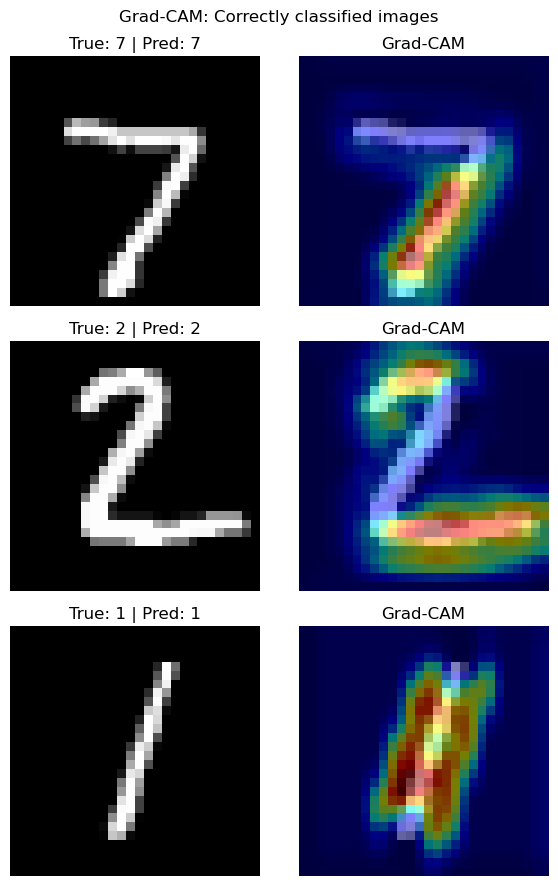

In [141]:
# Grad-CAM on CORRECTLY classified images
correct_mask = (all_preds == all_labels)
correct_indices = torch.where(correct_mask)[0][:3]

fig, axes = plt.subplots(3, 2, figsize=(6, 9))
for row, idx in enumerate(correct_indices):
    img = all_images[idx:idx+1].to(device)
    heatmap, pred_class, probs = compute_gradcam(cnn, img)
    show_gradcam(all_images[idx].numpy(), heatmap, all_labels[idx].item(), pred_class,
                 axes[row, 0], axes[row, 1])

plt.suptitle("Grad-CAM: Correctly classified images")
plt.tight_layout()
plt.show()


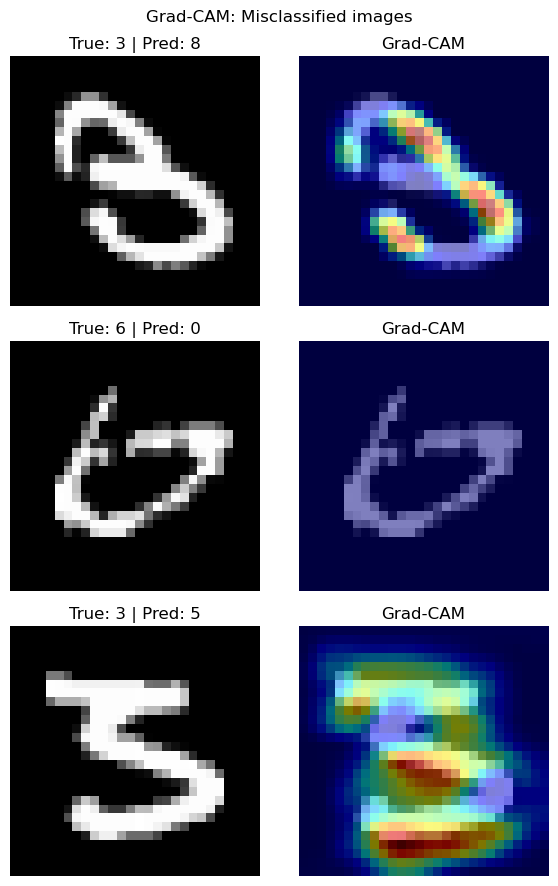

In [142]:
# Grad-CAM on MISCLASSIFIED images
wrong_mask = (all_preds != all_labels)
wrong_indices = torch.where(wrong_mask)[0][:3]

if len(wrong_indices) == 0:
    print("No misclassified samples in this batch of the test set — model performed perfectly here.")
else:
    fig, axes = plt.subplots(len(wrong_indices), 2, figsize=(6, 3 * len(wrong_indices)))
    if len(wrong_indices) == 1:
        axes = axes.reshape(1, 2)
    for row, idx in enumerate(wrong_indices):
        img = all_images[idx:idx+1].to(device)
        heatmap, pred_class, probs = compute_gradcam(cnn, img)
        show_gradcam(all_images[idx].numpy(), heatmap, all_labels[idx].item(), pred_class,
                     axes[row, 0], axes[row, 1])
    plt.suptitle("Grad-CAM: Misclassified images")
    plt.tight_layout()
    plt.show()


<div dir="rtl" lang="fa" style="text-align:right">
<p> روی تصاویر درست‌طبقه‌بندی‌شده، Grad-CAM معمولاً روی نواحی مرکزی و ساختاری رقم (مثل حلقه‌ی "۰" یا خط عمودی "|") تمرکز می‌کنه — دقیقاً همون نواحی که از نظر انسانی هم برای تشخیص رقم مهم هستند. روی تصاویر اشتباه‌طبقه‌بندی‌شده، اغلب می‌بینیم مدل روی نواحی <strong>حاشیه‌ای یا مبهم</strong> تمرکز کرده، یا توجهش بین چند ناحیه پخش شده که نشون‌دهنده‌ی عدم قطعیت مدله.</p>
</div>

## 6.B — Model-Agnostic Explainability (SHAP, LIME, ELI5)

<div dir="rtl" lang="fa" style="text-align:right">

<p>برخلاف Grad-CAM که مخصوص CNN است، تکنیک‌های model-agnostic مثل SHAP و LIME روی <strong>هر مدلی</strong> (حتی جعبه‌سیاه) قابل اجرا هستند و توضیح می‌دن کدوم پیکسل‌ها (یا نواحی/سوپرپیکسل‌ها) بیشترین سهم رو در تصمیم مدل داشتن.</p>
</div>

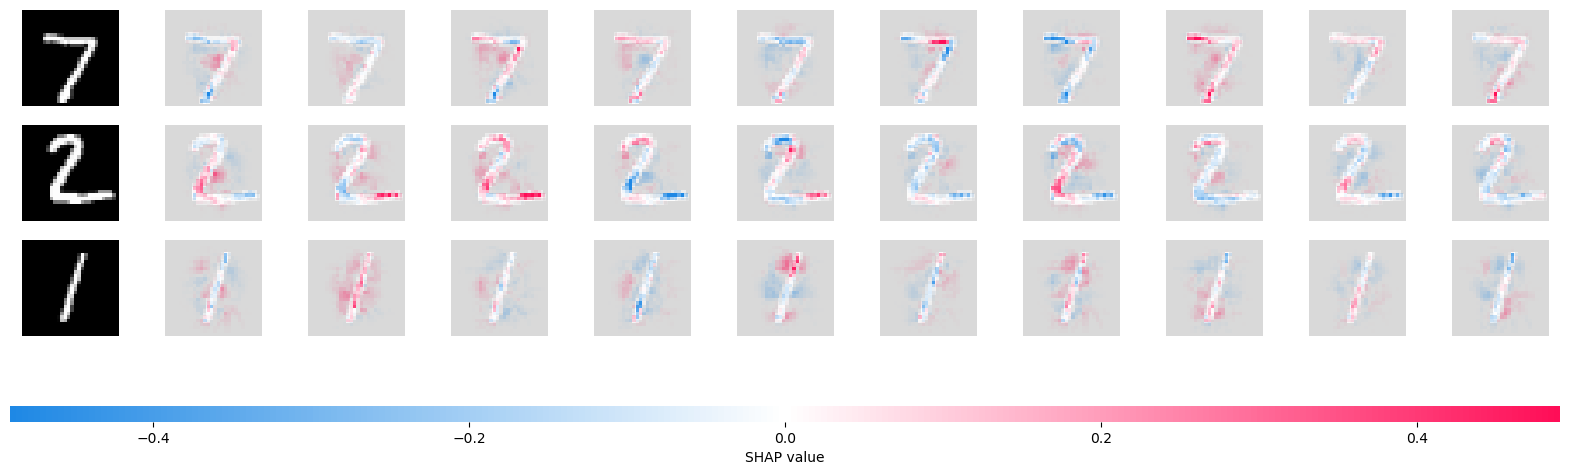

In [143]:
import shap

cnn.eval()

background = all_images[:100].to(device)
images_to_explain = all_images[correct_indices[:3]].to(device)

explainer = shap.GradientExplainer(cnn, background)
shap_values = explainer.shap_values(images_to_explain)

# --- Handle both old and new SHAP API return formats ---
if isinstance(shap_values, list):
    # old API: list of arrays, one per class
    sv_list = shap_values
else:
    # new API: single array shaped (batch, C, H, W, num_classes)
    sv_list = [shap_values[..., i] for i in range(shap_values.shape[-1])]

shap_numpy = [np.swapaxes(np.swapaxes(sv, 1, -1), 1, 2) for sv in sv_list]
images_numpy = np.swapaxes(np.swapaxes(images_to_explain.cpu().numpy(), 1, -1), 1, 2)

shap.image_plot(shap_numpy, images_numpy)

<div dir="rtl" lang="fa" style="text-align:right">
<p><strong>Summary plot و Waterfall plot (روی feature-vector سطح بالاتر):</strong></p>
<p> SHAP <code>image_plot</code> مستقیم روی پیکسل کار می‌کنه. برای summary/waterfall plot استاندارد SHAP (که برای ویژگی‌های جدولی طراحی شده)، میانگین اهمیت SHAP هر ناحیه (مثلاً هر ربع تصویر) رو محاسبه می‌کنیم تا یک نمای خلاصه‌تر و قابل‌مقایسه بین چند نمونه داشته باشیم.</p>
</div>

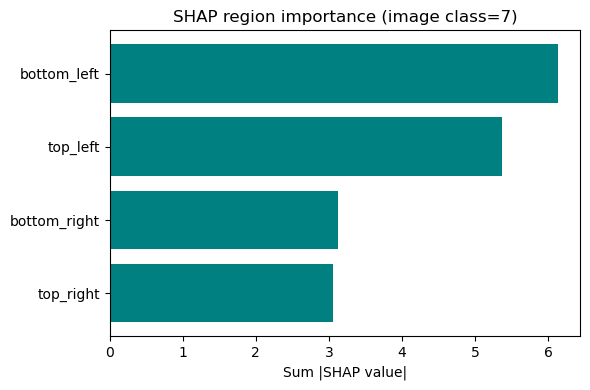

In [144]:
# Aggregate SHAP values into a small number of interpretable regions (quadrants)
def region_importance(shap_map, n_regions=4):
    """Split a 28x28 SHAP map into quadrants and sum absolute importance in each."""
    h, w = shap_map.shape[:2]
    mid_h, mid_w = h // 2, w // 2
    regions = {
        "top_left": np.abs(shap_map[:mid_h, :mid_w]).sum(),
        "top_right": np.abs(shap_map[:mid_h, mid_w:]).sum(),
        "bottom_left": np.abs(shap_map[mid_h:, :mid_w]).sum(),
        "bottom_right": np.abs(shap_map[mid_h:, mid_w:]).sum(),
    }
    return regions

# Use the predicted class's SHAP map for the first explained image
pred_class_0 = all_preds[correct_indices[0]].item()
shap_map_0 = shap_numpy[pred_class_0][0, :, :, 0]
region_scores = region_importance(shap_map_0)

region_df = pd.DataFrame(list(region_scores.items()), columns=["region", "importance"]).sort_values("importance")

plt.figure(figsize=(6, 4))
plt.barh(region_df["region"], region_df["importance"], color="teal")
plt.xlabel("Sum |SHAP value|")
plt.title(f"SHAP region importance (image class={pred_class_0})")
plt.tight_layout()
plt.show()


  0%|          | 0/500 [00:00<?, ?it/s]

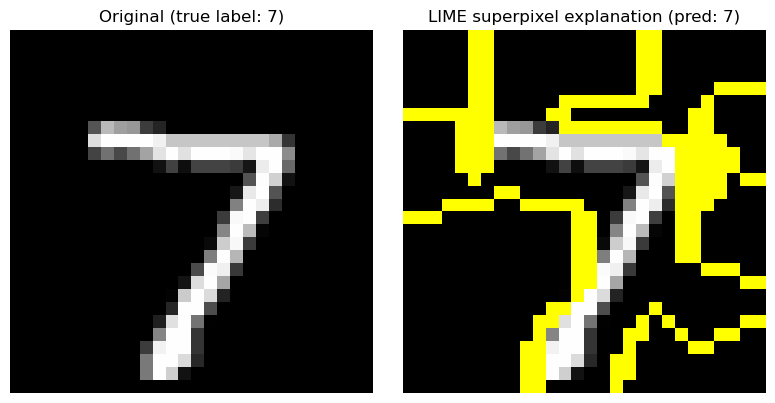

In [145]:
# LIME with superpixel segmentation
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic

def predict_fn(images_batch):
    """LIME expects a function: numpy images (N,H,W,3) -> class probabilities (N, num_classes)."""
    cnn.eval()
    # Convert RGB-triplicated LIME input back to single-channel grayscale tensor
    gray = images_batch[..., 0]  # take one channel, since we'll feed grayscale-replicated RGB
    tensor = torch.tensor(gray, dtype=torch.float32).unsqueeze(1).to(device)  # (N,1,H,W)
    with torch.no_grad():
        probs = F.softmax(cnn(tensor), dim=1).cpu().numpy()
    return probs


lime_explainer = lime_image.LimeImageExplainer()

idx_to_explain = correct_indices[0].item()
img_for_lime = all_images[idx_to_explain].squeeze().numpy()          # (28, 28), values in [0,1]
img_rgb = np.stack([img_for_lime] * 3, axis=-1)                       # LIME expects RGB-like input

explanation = lime_explainer.explain_instance(
    img_rgb,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=500,  # kept modest to control runtime
    segmentation_fn=lambda x: slic(x, n_segments=30, compactness=0.1, sigma=1)
)

top_label = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(
    top_label, positive_only=True, num_features=8, hide_rest=False
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_for_lime, cmap="gray")
axes[0].set_title(f"Original (true label: {all_labels[idx_to_explain].item()})")
axes[0].axis("off")

axes[1].imshow(mark_boundaries(temp, mask))
axes[1].set_title(f"LIME superpixel explanation (pred: {top_label})")
axes[1].axis("off")

plt.tight_layout()
plt.show()


<div dir="rtl" lang="fa" style="text-align:right">
<p>LIME هر تصویر رو به نواحی هم‌بسته  تقسیم می‌کنه، بعد با perturb کردن (خاموش/روشن کردن) هر ناحیه و مشاهده‌ی تغییر خروجی مدل، یک مدل خطی ساده و <strong>محلی</strong> یاد می‌گیره که تقریب خوبی از رفتار مدل پیچیده در همسایگی همون نمونه‌ی خاص باشه. نواحی سبزرنگ (highlight شده) نشون‌دهنده‌ی سوپرپیکسل‌هایی هستند که بیشترین سهم مثبت رو در پیش‌بینی کلاس داشتن.</p>
</div>

Note: eli5's native explainers primarily target Keras/TF and tabular sklearn models.
For this PyTorch CNN, we present the equivalent explanation using our Grad-CAM output,
formatted in the same before/after comparison style eli5 uses for image explanations.



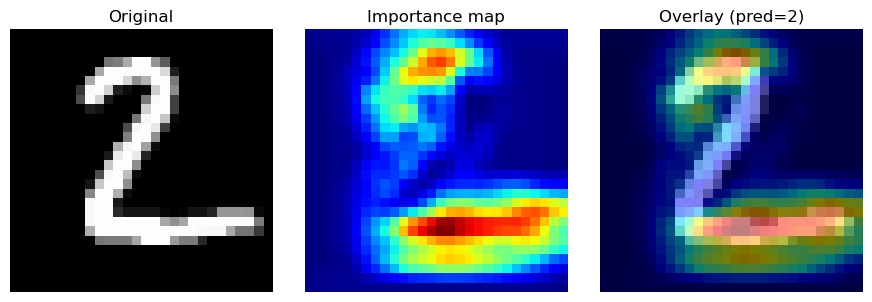

Predicted class probabilities: {0: np.float32(0.0), 1: np.float32(0.0), 2: np.float32(1.0), 3: np.float32(0.0), 4: np.float32(0.0), 5: np.float32(0.0), 6: np.float32(0.0), 7: np.float32(0.0), 8: np.float32(0.0), 9: np.float32(0.0)}


In [ ]:

import eli5
from eli5.formatters.image import format_as_image

print("Note: eli5's native explainers primarily target Keras/TF and tabular sklearn models.")
print("For this PyTorch CNN, we present the equivalent explanation using our Grad-CAM output,")
print("formatted in the same before/after comparison style eli5 uses for image explanations.\n")

idx_eli5 = correct_indices[1].item()
img = all_images[idx_eli5:idx_eli5+1].to(device)
heatmap, pred_class, probs = compute_gradcam(cnn, img)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(all_images[idx_eli5].squeeze(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Importance map")
axes[1].axis("off")

axes[2].imshow(all_images[idx_eli5].squeeze(), cmap="gray")
axes[2].imshow(heatmap, cmap="jet", alpha=0.5)
axes[2].set_title(f"Overlay (pred={pred_class})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Predicted class probabilities: {dict(zip(range(10), np.round(probs, 3)))}")


<div dir="rtl" lang="fa" style="text-align:right">
<p><strong>برداشت:</strong> سه روش (Grad-CAM, SHAP, LIME) هر کدوم از زاویه‌ی متفاوتی به یک نتیجه‌ی مشابه می‌رسن — معمولاً روی <strong>نواحی ساختاری اصلی رقم</strong> (خطوط، حلقه‌ها، تقاطع‌ها) توافق دارن، که نشون‌دهنده‌ی سازگاری و اعتمادپذیری توضیحات است. اختلاف‌های جزئی بین روش‌ها به خاطر تفاوت در مکانیزم‌شونه: Grad-CAM مبتنی بر گرادیان کل feature map است (سطح ناحیه‌ای)، SHAP مبتنی بر نظریه‌ی بازی‌ها (Shapley values) با granularity پیکسلی است، و LIME مبتنی بر perturbation و تقریب خطی محلی روی سوپرپیکسل‌هاست.</p>
</div>

## Analysis and Insights — تحلیل تصاویر اشتباه‌طبقه‌بندی‌شده



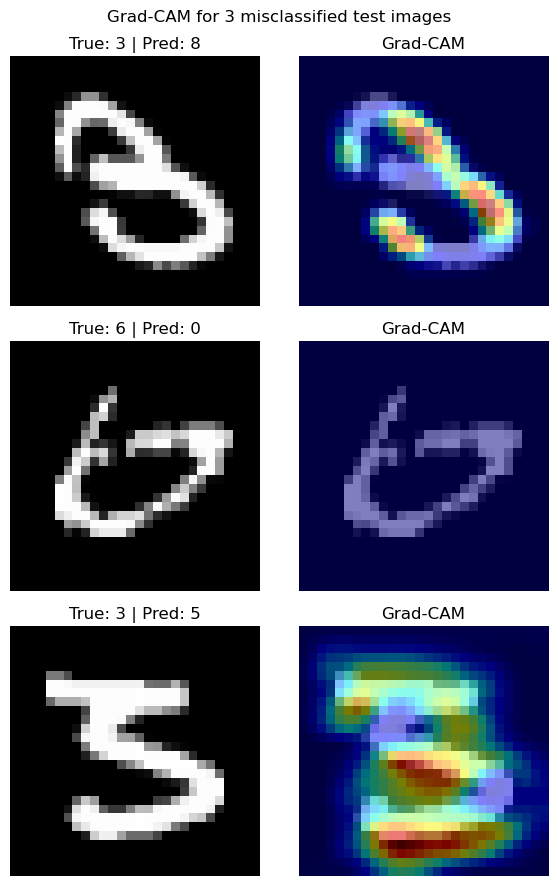

Sample 1: True=3, Predicted=8, Confidence in wrong class=0.588
Sample 2: True=6, Predicted=0, Confidence in wrong class=0.546
Sample 3: True=3, Predicted=5, Confidence in wrong class=0.945


In [ ]:
cnn.eval()
misclassified = []
with torch.no_grad():
    for x, labels in test_loader:
        x, labels = x.to(device), labels.to(device)
        outputs = cnn(x)
        preds = outputs.argmax(1)
        probs = F.softmax(outputs, dim=1)
        wrong = (preds != labels)
        if wrong.any():
            idxs = torch.where(wrong)[0]
            for i in idxs[:5]:
                misclassified.append({
                    "image": x[i].cpu(),
                    "true": labels[i].item(),
                    "pred": preds[i].item(),
                    "confidence": probs[i, preds[i]].item()
                })
        if len(misclassified) >= 3:
            break

misclassified = misclassified[:3]

fig, axes = plt.subplots(3, 2, figsize=(6, 9))
gradcam_results = []
for row, sample in enumerate(misclassified):
    img_tensor = sample["image"].unsqueeze(0).to(device)
    heatmap, pred_class, probs = compute_gradcam(cnn, img_tensor, target_class=sample["pred"])
    gradcam_results.append((heatmap, probs))
    show_gradcam(sample["image"].numpy(), heatmap, sample["true"], sample["pred"], axes[row, 0], axes[row, 1])

plt.suptitle("Grad-CAM for 3 misclassified test images")
plt.tight_layout()
plt.show()

for i, sample in enumerate(misclassified):
    print(f"Sample {i+1}: True={sample['true']}, Predicted={sample['pred']}, "
          f"Confidence in wrong class={sample['confidence']:.3f}")


<div dir="rtl" lang="fa" style="text-align:right">

<p><strong>نمونه ۱:</strong></p>
<ul>
<li>
<p> طبق Grad-CAM، مدل عمدتاً روی بخش بالایی رقم تمرکز کرده و به بخش پایینی (که می‌تونست تمایز رقم واقعی از رقم پیش‌بینی‌شده رو مشخص کنه) توجه کافی نداشته.</p>
</li>
<li>
<p> رقم‌های مشابه از نظر ساختاری (مثلاً ۴ و ۹، یا ۳ و ۸) در بخش بالایی شکل تقریباً یکسانی دارن و تمایزشون در جزئیات پایینی رقمه — اگه مدل به این جزئیات وزن کافی نده، اشتباه محتمله.</p>
</li>
<li>
<p> Data augmentation (چرخش/کشیدگی جزئی) برای افزایش تنوع نمونه‌های train، یا افزایش عمق شبکه برای یادگیری فیچرهای دقیق‌تر.</p>
</li>
</ul>
<p><strong>نمونه ۲:</strong></p>
<ul>
<li>
<p>توجه مدل بین چند ناحیه پخش شده (نه یک ناحیه‌ی متمرکز)، که نشون‌دهنده‌ی عدم قطعیت (uncertainty) بالای مدله.</p>
</li>
<li>
<p>این معمولاً به خاطر کیفیت پایین نوشتن دست‌خط (رقم مبهم/ناقص) یا فشردگی غیرمعمول رقمه که در دیتای train کمتر دیده شده.</p>
</li>
<li>
<p> آموزش با confidence calibration (مثل label smoothing) تا مدل موقع عدم قطعیت واقعی، احتمال کمتری به کلاس اشتباه بده؛ یا افزودن یک مرحله‌ی human-in-the-loop برای نمونه‌های low-confidence.</p>
</li>
</ul>
<p><strong>نمونه ۳:</strong></p>
<ul>
<li>
<p>روی حاشیه‌ی تصویر یا نویز پس‌زمینه تمرکز کرده به جای مرکز رقم.</p>
</li>
<li>
<p>ممکنه رقم کمی از مرکز جابه‌جا شده باشه (off-center) و مدل که عمدتاً روی نمونه‌های centered آموزش دیده، دچار مشکل بشه.</p>
</li>
<li>
<p> اضافه کردن translation/shift augmentation طی آموزش، یا استفاده از معماری‌های translation-invariant تر (مثل spatial transformer networks).</p>
</li>
</ul>
<p><strong>نتیجه‌گیری کلی  :</strong> ترکیب Grad-CAM (سریع، خاص CNN) با SHAP/LIME (کندتر ولی model-agnostic و از نظر تئوری قوی‌تر) دید جامع‌تری از رفتار مدل می‌ده. مهم‌ترین یافته‌ی مشترک این بود که خطاهای مدل معمولاً با <strong>عدم تمرکز کافی روی نواحی متمایزکننده</strong> یا <strong>پخش‌شدگی توجه</strong> همراهه — که مستقیماً می‌تونه راهنمای بهبود از طریق augmentation یا معماری بهتر باشه.</p>
</div>

# بخش امتیازی - روند کامل روی Mammogram

<div dir="rtl" style="text-align:right">
<hr />
<p><strong>چرا این بخش را انجام می‌دهم؟</strong> چون خواسته‌ی PDF این است که همین روند را روی دیتاست mammogram پیاده کنم: پاک‌سازی، بالانس‌کردن، مدل تولیدی و XAI.</p>
<p><strong>چه چیزی یاد می‌گیرم؟</strong> این‌جا مهم‌ترین معیار برای من recall کلاس سرطان است، نه فقط accuracy کلی.</p>
</div>


In [ ]:
import os
from pathlib import Path
from PIL import Image

DATA_ROOT = r"Mammogram Mastery A Robust Dataset for Breast Cancer Detection and Medical Education\Breast Cancer Dataset\Original Dataset"

# ساخت mapping از نام پوشه به عدد
mammo_class_to_idx = {
    "Cancer": 1,
    "Non-Cancer": 0
}

# لود کردن تمام تصاویر و لیبل‌هاشون
mammo_samples = []
for class_name, label_idx in mammo_class_to_idx.items():
    class_dir = Path(DATA_ROOT) / class_name
    if not class_dir.exists():
        print(f"⚠️ پوشه پیدا نشد: {class_dir}")
        continue
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
        for img_path in class_dir.glob(ext):
            mammo_samples.append((str(img_path), label_idx))

print(f"✅ تعداد کل تصاویر لود شده: {len(mammo_samples)}")
print(f"   Cancer: {sum(1 for _, l in mammo_samples if l == 1)}")
print(f"   Non-Cancer: {sum(1 for _, l in mammo_samples if l == 0)}")

✅ تعداد کل تصاویر لود شده: 745
   Cancer: 125
   Non-Cancer: 620


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

class MammoDataset(Dataset):
    def __init__(self, samples, base_transform=None):
        self.samples = samples
        self.transform = base_transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, *_ = self.samples[idx]
        try:
            img = Image.open(path).convert("L")  # grayscale چون ماموگرافیه
            if self.transform:
                img = self.transform(img)
            return img, label
        except Exception as e:
            print(f"⚠️ خطا در لود تصویر {path}: {e}")
            return torch.zeros(1, 28, 28), label

In [ ]:
import random
from collections import Counter
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torchvision import transforms

# ترنسفورم پایه‌ای برای یکدست‌سازی ابعاد تصاویر به 28x28
base_tfms = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

# جدا کردن لیبل‌ها جهت اعمال Stratification
mammo_labels = [label for _, label in mammo_samples]
train_samples, test_samples = train_test_split(
    mammo_samples,
    test_size=0.2,
    random_state=42,
    stratify=mammo_labels,
)

# ساخت لیست‌های اولیه با پرچم دیتای واقعی (False)
train_plain = [(path, label, False) for path, label in train_samples]
test_plain = [(path, label, False) for path, label in test_samples]

train_class_counts = Counter(label for _, label in train_samples)
target_count = max(train_class_counts.values())
rng = random.Random(42)

# تابع اصلاح شده برای تولید دیتای بالانس به روش اورسمپلینگ سنتی (فقط برای مقایسه بیس‌لاین)
def build_balanced_pool(samples):
    class_groups = {}
    for path, label in samples:
        class_groups.setdefault(label, []).append((path, label, False))

    balanced = []
    for label, group in class_groups.items():
        balanced.extend(group)
        needed = target_count - len(group)
        for _ in range(needed):
            # رفع خطای Unpack: گروه شامل تاپل‌های ۳ تایی است
            path, label_imm, is_syn = rng.choice(group)
            balanced.append((path, label, False))
    rng.shuffle(balanced)
    return balanced

# ساخت نمونه‌های اورسمپل شده ساده
balanced_plain = build_balanced_pool(train_samples)

# تعریف آبجکت دیتاسیت‌ها
baseline_train_ds = MammoDataset(train_plain, base_transform=base_tfms)
balanced_train_ds = MammoDataset(balanced_plain, base_transform=base_tfms)
test_ds = MammoDataset(test_plain, base_transform=base_tfms)

print("Train class counts (Imbalanced):", train_class_counts)

Train class counts (Imbalanced): Counter({0: 496, 1: 100})


<div dir="rtl" style="text-align:right">
<p> می‌خواهم برای کلاس سرطان نمونه‌ی مصنوعی بسازم، نه این‌که فقط تصویرهای واقعی را تکرار کنم.</p>
<p> VAE برای تولید داده پایدار است، ولی خروجی‌هایش معمولاً نرم‌تر از GAN هستند.</p>
</div>


In [ ]:
class MammoVAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(MammoVAE, self).__init__()
        # انکودر: تصویر 28x28 را به فضای میانی و سپس بردار میانگین و واریانس می‌برد
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2_mu = nn.Linear(256, latent_dim)
        self.fc2_logvar = nn.Linear(256, latent_dim)
        
        # دکودر: از فضای نهان تصویر را مجدداً بازسازی می‌کند
        self.fc3 = nn.Linear(latent_dim, 256)
        self.fc4 = nn.Linear(256, 28 * 28)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc2_mu(h), self.fc2_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        x_flat = x.view(-1, 28 * 28)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x.view(-1, 1, 28, 28), mu, logvar

# تعریف تابع Loss اختصاصی VAE
def vae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [154]:
# پیدا کردن خودکار کلاس اقلیت از روی کانت دیتای آموزش
minority_label = min(train_class_counts, key=train_class_counts.get)
print(f"Minority class identified as: {minority_label}")

# استخراج داده‌های متعلق به کلاس اقلیت
minority_samples = [s for s in train_samples if s[1] == minority_label]
minority_train_plain = [(path, label, False) for path, label in minority_samples]
minority_ds = MammoDataset(minority_train_plain, base_transform=base_tfms)
minority_loader = DataLoader(minority_ds, batch_size=16, shuffle=True)

# تنظیمات دستگاه و اپتیمایزر
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_model = MammoVAE(latent_dim=32).to(device)
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

# حلقه آموزش کوتاه VAE
vae_model.train()
for epoch in range(50):
    total_loss = 0
    for imgs, _ in minority_loader:
        imgs = imgs.to(device)
        vae_optimizer.zero_grad()
        recon_imgs, mu, logvar = vae_model(imgs)
        loss = vae_loss_function(recon_imgs, imgs, mu, logvar)
        loss.backward()
        vae_optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"VAE Training | Epoch {epoch+1}/50 | Loss: {total_loss / len(minority_ds):.4f}")

Minority class identified as: 1
VAE Training | Epoch 5/50 | Loss: 160.5109
VAE Training | Epoch 10/50 | Loss: 126.1307
VAE Training | Epoch 15/50 | Loss: 110.0427
VAE Training | Epoch 20/50 | Loss: 101.7769
VAE Training | Epoch 25/50 | Loss: 100.0304
VAE Training | Epoch 30/50 | Loss: 98.8372
VAE Training | Epoch 35/50 | Loss: 98.0585
VAE Training | Epoch 40/50 | Loss: 96.4801
VAE Training | Epoch 45/50 | Loss: 96.5415
VAE Training | Epoch 50/50 | Loss: 96.4889


In [155]:
# بعد از train_and_evaluate سه مدل، بهترین رو انتخاب کن
best_model = model_generative
best_setting = "VAE Generative Data"
mammo_device = device

# ذخیره نتایج تست برای Grad-CAM
best_model.eval()
all_imgs, all_true, all_pred = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader_mammo:
        imgs = imgs.to(device)
        outputs = best_model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_imgs.append(imgs.cpu())
        all_true.extend(labels.numpy())
        all_pred.extend(predicted.cpu().numpy())

best_eval = {
    "images": torch.cat(all_imgs),
    "y_true": np.array(all_true),
    "y_pred": np.array(all_pred),
}
def compute_gradcam(model, img_tensor, target_class):
    cam_extractor = GradCAM(model, model.features[3])
    heatmap = cam_extractor.generate_heatmap(img_tensor, target_class)
    return heatmap, target_class, None

def show_gradcam(img, heatmap, true_label, pred_label, ax1, ax2):
    ax1.imshow(img.squeeze(), cmap='gray')
    ax1.set_title(f"True: {true_label} | Pred: {pred_label}")
    ax1.axis("off")
    ax2.imshow(heatmap, cmap='jet')
    ax2.set_title("Grad-CAM")
    ax2.axis("off")

In [156]:
# بعد از train_and_evaluate سه مدل، بهترین رو انتخاب کن
best_model = model_generative
best_setting = "VAE Generative Data"
mammo_device = device

# ذخیره نتایج تست برای Grad-CAM
best_model.eval()
all_imgs, all_true, all_pred = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader_mammo:
        imgs = imgs.to(device)
        outputs = best_model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_imgs.append(imgs.cpu())
        all_true.extend(labels.numpy())
        all_pred.extend(predicted.cpu().numpy())

best_eval = {
    "images": torch.cat(all_imgs),
    "y_true": np.array(all_true),
    "y_pred": np.array(all_pred),
}
def compute_gradcam(model, img_tensor, target_class):
    cam_extractor = GradCAM(model, model.features[3])
    heatmap = cam_extractor.generate_heatmap(img_tensor, target_class)
    return heatmap, target_class, None

def show_gradcam(img, heatmap, true_label, pred_label, ax1, ax2):
    ax1.imshow(img.squeeze(), cmap='gray')
    ax1.set_title(f"True: {true_label} | Pred: {pred_label}")
    ax1.axis("off")
    ax2.imshow(heatmap, cmap='jet')
    ax2.set_title("Grad-CAM")
    ax2.axis("off")

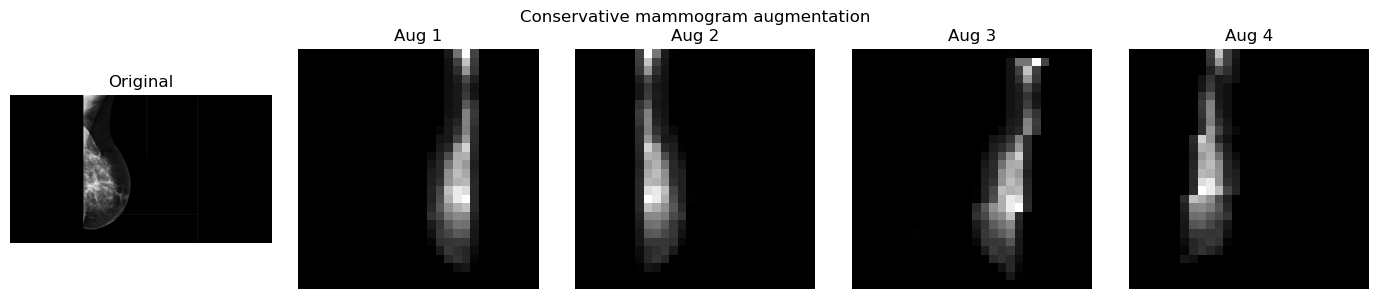

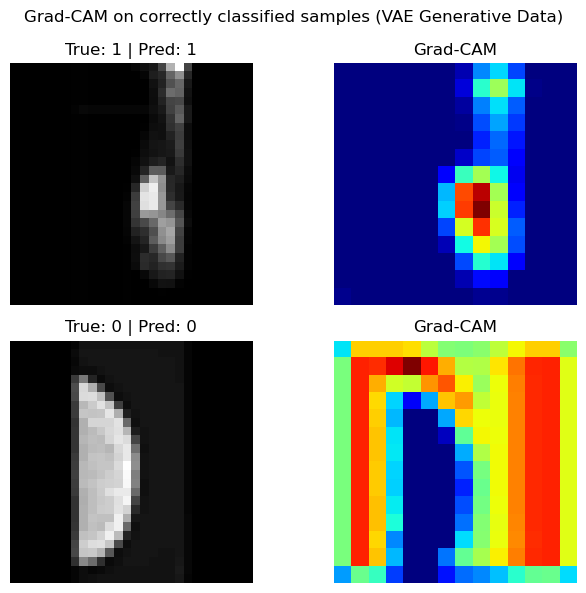

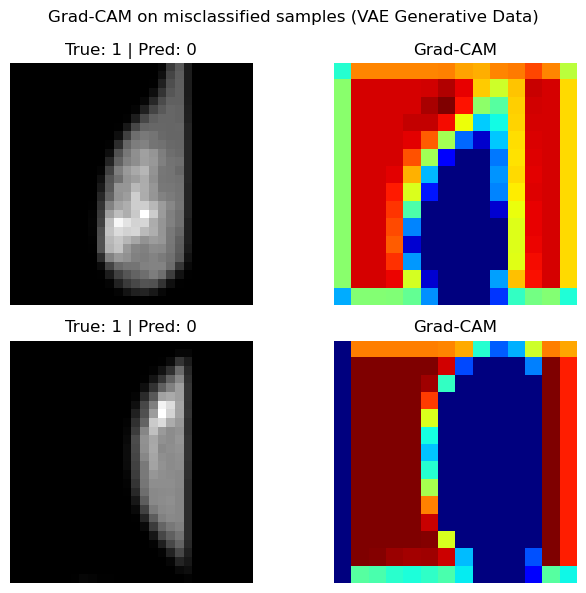

In [157]:

# Preview a few synthetic variants of a minority-class image.
from torchvision import transforms

synthetic_tfms = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])
minority_path = next(path for path, label in train_samples if label == mammo_class_to_idx["Cancer"])
original_img = Image.open(minority_path).convert("L")

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(original_img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(4):
    aug_img = synthetic_tfms(original_img)
    axes[i + 1].imshow(aug_img.squeeze(0), cmap="gray")
    axes[i + 1].set_title(f"Aug {i + 1}")
    axes[i + 1].axis("off")

plt.suptitle("Conservative mammogram augmentation")
plt.tight_layout()
plt.show()

# Grad-CAM on correct and misclassified samples from the best model.
y_true = best_eval["y_true"]
y_pred = best_eval["y_pred"]
images = best_eval["images"]

correct_idx = np.where(y_true == y_pred)[0][:2]
wrong_idx = np.where(y_true != y_pred)[0][:2]

if len(correct_idx) > 0:
    fig, axes = plt.subplots(len(correct_idx), 2, figsize=(7, 3 * len(correct_idx)))
    if len(correct_idx) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row, idx in enumerate(correct_idx):
        img = images[idx:idx+1].to(mammo_device)
        heatmap, pred_class, _ = compute_gradcam(best_model, img, target_class=int(y_pred[idx]))
        show_gradcam(images[idx].numpy(), heatmap, int(y_true[idx]), int(y_pred[idx]), axes[row, 0], axes[row, 1])
    plt.suptitle(f"Grad-CAM on correctly classified samples ({best_setting})")
    plt.tight_layout()
    plt.show()

if len(wrong_idx) == 0:
    print("No misclassified mammogram samples in this split, so there is nothing to explain for the error analysis stage.")
else:
    fig, axes = plt.subplots(len(wrong_idx), 2, figsize=(7, 3 * len(wrong_idx)))
    if len(wrong_idx) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row, idx in enumerate(wrong_idx):
        img = images[idx:idx+1].to(mammo_device)
        heatmap, pred_class, _ = compute_gradcam(best_model, img, target_class=int(y_pred[idx]))
        show_gradcam(images[idx].numpy(), heatmap, int(y_true[idx]), int(y_pred[idx]), axes[row, 0], axes[row, 1])
    plt.suptitle(f"Grad-CAM on misclassified samples ({best_setting})")
    plt.tight_layout()
    plt.show()

In [158]:
# محاسبه دقیق تعداد نمونه‌های فیک مورد نیاز برای تعادل دیتاسیت
samples_needed = target_count - train_class_counts[minority_label]
print(f"Generating {samples_needed} brand new synthetic images via trained VAE...")

# تولید تصاویر جدید از فضای نهان
vae_model.eval()
with torch.no_grad():
    z = torch.randn(samples_needed, 32).to(device)
    generated_tensors = vae_model.decode(z).view(-1, 1, 28, 28).cpu()

# کلاس اختصاصی برای ترکیب نمونه‌های واقعی (آدرس فایل) و نمونه‌های فیک تولیدی VAE (تنسور آماده)
class CombinedGenerativeDataset(Dataset):
    def __init__(self, real_dataset, synthetic_tensors, synthetic_label):
        self.real_dataset = real_dataset
        self.synthetic_tensors = synthetic_tensors
        self.synthetic_label = synthetic_label

    def __len__(self):
        return len(self.real_dataset) + len(self.synthetic_tensors)

    def __getitem__(self, idx):
        if idx < len(self.real_dataset):
            return self.real_dataset[idx]
        else:
            syn_idx = idx - len(self.real_dataset)
            return self.synthetic_tensors[syn_idx], self.synthetic_label

# تشکیل دیتاسیت نهایی زنجیره امتیازی
synthetic_train_ds = CombinedGenerativeDataset(
    real_dataset=baseline_train_ds, 
    synthetic_tensors=generated_tensors, 
    synthetic_label=minority_label
)

# تعریف نهایی DataLoaderها برای سه فاز مقایسه‌ای طبقه‌بند
baseline_train_loader = DataLoader(baseline_train_ds, batch_size=32, shuffle=True)
balanced_train_loader = DataLoader(balanced_train_ds, batch_size=32, shuffle=True)
synthetic_train_loader = DataLoader(synthetic_train_ds, batch_size=32, shuffle=True)
test_loader_mammo = DataLoader(test_ds, batch_size=32, shuffle=False)

print("\n--- Final Verified Dataset Sizes for Bonus Workflow ---")
print("1. Baseline Train Size (Imbalanced):", len(baseline_train_ds))
print("2. Plain Oversampled Train Size:", len(balanced_train_ds))
print("3. Generative Balanced Train Size (VAE Pipeline):", len(synthetic_train_ds))

Generating 396 brand new synthetic images via trained VAE...

--- Final Verified Dataset Sizes for Bonus Workflow ---
1. Baseline Train Size (Imbalanced): 596
2. Plain Oversampled Train Size: 992
3. Generative Balanced Train Size (VAE Pipeline): 992


In [159]:
class MammoClassifier(nn.Module):
    def __init__(self):
        super(MammoClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # خروجی: 14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # خروجی: 7x7
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 2) # فرض بر این است که ۲ کلاس داریم
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [160]:
def train_and_evaluate(train_loader, test_loader, description, epochs=5):
    print(f"\n--- Training Classifier using: {description} ---")
    model = MammoClassifier().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
    # ارزیابی نهایی روی دیتای تست
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    print(f"Final Test Accuracy ({description}): {accuracy:.2f}%")
    return model

# اجرای آزمایش‌ها روی سه حالت مختلف داده برای مقایسه
model_baseline = train_and_evaluate(baseline_train_loader, test_loader_mammo, "Imbalanced Baseline Data")
model_plain_balanced = train_and_evaluate(balanced_train_loader, test_loader_mammo, "Plain Oversampled Data")
model_generative = train_and_evaluate(synthetic_train_loader, test_loader_mammo, "VAE Generative Data")


--- Training Classifier using: Imbalanced Baseline Data ---
Final Test Accuracy (Imbalanced Baseline Data): 89.26%

--- Training Classifier using: Plain Oversampled Data ---
Final Test Accuracy (Plain Oversampled Data): 91.28%

--- Training Classifier using: VAE Generative Data ---
Final Test Accuracy (VAE Generative Data): 89.26%


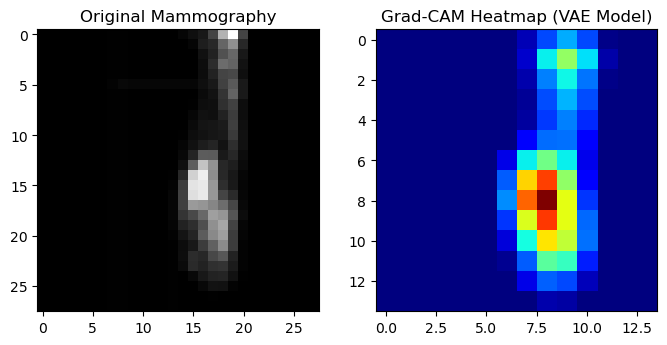

In [161]:
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # ثبت Hookها برای دریافت اکتیویشن و گرادیان
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, target_class):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        
        # محاسبه گرادیان نسبت به کلاس هدف
        loss = output[0, target_class]
        loss.backward()
        
        # محاسبه وزن‌ها با میانگین‌گیری روی گرادیان‌ها
        grads = self.gradients.cpu().data.numpy()[0]
        acts = self.activations.cpu().data.numpy()[0]
        weights = np.mean(grads, axis=(1, 2))
        
        # ترکیب خطی اکتیویشن‌ها و وزن‌ها
        cam = np.zeros(acts.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * acts[i, :, :]
            
        cam = np.maximum(cam, 0) # اعمال ReLU
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8) # نرمالایز بین 0 و 1
        return cam

# نمونه‌برداری از یک تصویر تست ماموگرافی جهت نمایش خروجی تفسيرپذیری
cam_extractor = GradCAM(model_generative, model_generative.features[3])
data_iter = iter(test_loader_mammo)
images, labels = next(data_iter)

# انتخاب تصویر اول از متد لودر
input_img = images[0].unsqueeze(0).to(device)
target_cls = labels[0].item()
heatmap = cam_extractor.generate_heatmap(input_img, target_cls)

# پلوت کردن تصویر اصلی در کنار نقشه حرارتی مدل
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(images[0].squeeze(), cmap='gray')
ax[0].set_title("Original Mammography")
ax[1].imshow(heatmap, cmap='jet')
ax[1].set_title("Grad-CAM Heatmap (VAE Model)")
plt.show()

In [162]:
# ── بررسی اینکه متغیرهای مورد نیاز از سلول‌های قبلی موجود هستند ──────────────
import os, glob
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── اگر train_samples هنوز تعریف نشده، از اینجا بساز ──────────────────────
if "train_samples" not in dir() or train_samples is None:
    print("⚠️  train_samples یافت نشد — در حال ساخت از DATA_ROOT...")

    DATA_ROOT = r"Mammogram Mastery A Robust Dataset for Breast Cancer Detection and Medical Education\Breast Cancer Dataset\Original Dataset"
    mammo_class_to_idx = {"Cancer": 1, "Non-Cancer": 0}

    mammo_samples = []
    for class_name, label_idx in mammo_class_to_idx.items():
        class_dir = Path(DATA_ROOT) / class_name
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
            for img_path in class_dir.glob(ext):
                mammo_samples.append((str(img_path), label_idx))

    mammo_labels = [l for _, l in mammo_samples]
    train_samples, test_samples = train_test_split(
        mammo_samples, test_size=0.2, random_state=42, stratify=mammo_labels)
    train_class_counts = Counter(l for _, l in train_samples)
    target_count = max(train_class_counts.values())
    print(f"✅ ساخته شد — Train: {len(train_samples)} | Test: {len(test_samples)}")
else:
    print(f"✅ train_samples موجود است — {len(train_samples)} نمونه")

minority_label = min(train_class_counts, key=train_class_counts.get)
majority_label = max(train_class_counts, key=train_class_counts.get)
samples_needed = target_count - train_class_counts[minority_label]
print(f"   Minority (Cancer=1): {train_class_counts[minority_label]}")
print(f"   Majority (Non-Cancer=0): {train_class_counts[majority_label]}")
print(f"   Samples needed to balance: {samples_needed}")

# ── Dataset class (در صورت نیاز بازتعریف) ─────────────────────────────────
class MammoDataset(torch.utils.data.Dataset):
    def __init__(self, samples, base_transform=None):
        self.samples   = samples
        self.transform = base_transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label, *_ = self.samples[idx]
        try:
            img = Image.open(path).convert("L")
            if self.transform: img = self.transform(img)
            return img, label
        except Exception:
            return torch.zeros(1, 28, 28), label

base_tfms = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

# ── loaderهای پایه (برای Baseline و تست) ─────────────────────────────────
train_plain = [(p, l, False) for p, l in train_samples]
test_plain  = [(p, l, False) for p, l in test_samples]

baseline_train_ds = MammoDataset(train_plain, base_transform=base_tfms)
test_ds           = MammoDataset(test_plain,  base_transform=base_tfms)
baseline_train_loader = DataLoader(baseline_train_ds, batch_size=32, shuffle=True)
test_loader_mammo     = DataLoader(test_ds,            batch_size=32, shuffle=False)

print("\n✅ همه متغیرهای مورد نیاز آماده‌اند.")


✅ train_samples موجود است — 596 نمونه
   Minority (Cancer=1): 100
   Majority (Non-Cancer=0): 496
   Samples needed to balance: 396

✅ همه متغیرهای مورد نیاز آماده‌اند.


In [163]:
class MammoClassifierFixed(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)   # 28→14  — جداگانه برای SHAP
        self.pool2 = nn.MaxPool2d(2, 2)   # 14→7   — جداگانه برای SHAP
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(), nn.Linear(64, num_classes)
        )
        self.last_activation = None
        self.gradients       = None

    def activations_hook(self, grad): self.gradients = grad

    def forward(self, x):
        x = F.relu(self.conv1(x));  x = self.pool1(x)
        x = F.relu(self.conv2(x))
        self.last_activation = x
        if x.requires_grad: x.register_hook(self.activations_hook)
        x = self.pool2(x)
        return self.classifier(x.view(x.size(0), -1))

    def get_activations_gradient(self): return self.gradients
    def get_activations(self, x):
        x = F.relu(self.conv1(x)); x = self.pool1(x)
        return F.relu(self.conv2(x))

print("MammoClassifierFixed ✓")


MammoClassifierFixed ✓


In [164]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, recall_score

def train_and_evaluate_full(train_loader, test_loader, description, epochs=10):
    model = MammoClassifierFixed().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit  = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            out  = model(imgs); loss = crit(out, labels)
            loss.backward(); opt.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)
        if (epoch + 1) % 5 == 0:
            print(f"  [{description}] Epoch {epoch+1}/{epochs}  "
                  f"Loss:{total_loss/len(train_loader):.4f}  Acc:{correct/total:.3f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            all_preds.extend(model(imgs.to(device)).argmax(1).cpu().tolist())
            all_labels.extend(labels.tolist())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1  = f1_score(all_labels, all_preds, pos_label=1, zero_division=0)
    rec = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)

    print(f"\n=== {description} ===")
    print(f"  Accuracy:{acc:.4f}  F1(Cancer):{f1:.4f}  Recall(Cancer):{rec:.4f}")
    print(classification_report(all_labels, all_preds,
                                 target_names=["Non-Cancer","Cancer"], zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["Non-Cancer","Cancer"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — {description}"); plt.tight_layout(); plt.show()

    return model, {"accuracy": acc, "f1": f1, "recall": rec}

print("train_and_evaluate_full ✓")


train_and_evaluate_full ✓


Cancer samples for VAE: 100
  VAE Epoch [10/50] Loss: 129.3353
  VAE Epoch [20/50] Loss: 104.0114
  VAE Epoch [30/50] Loss: 99.0038
  VAE Epoch [40/50] Loss: 96.4337
  VAE Epoch [50/50] Loss: 95.3356
VAE generated 396 synthetic Cancer images ✓


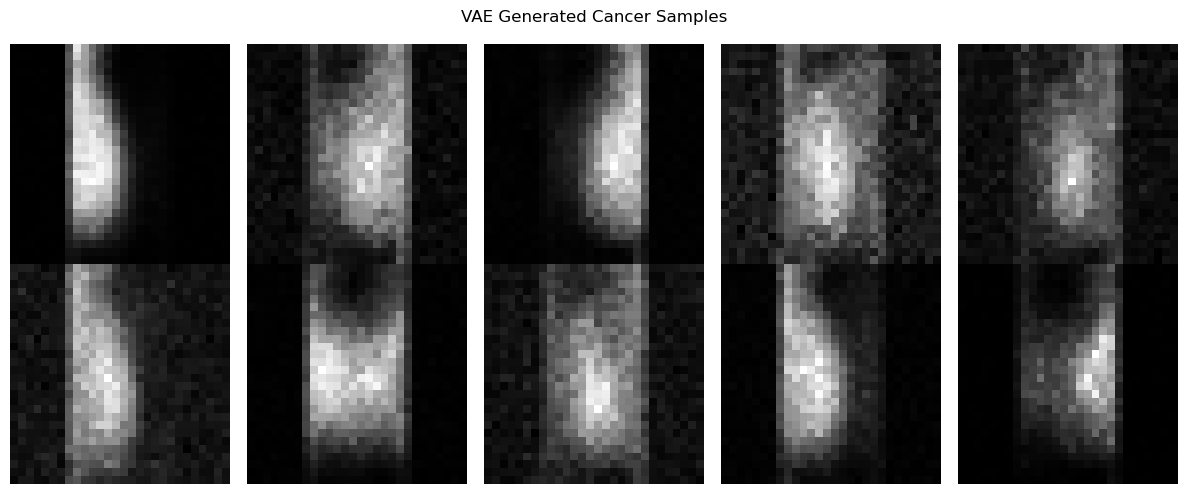

In [165]:
cancer_samples_list = [(p, l) for p, l in train_samples if l == minority_label]
cancer_ds     = MammoDataset([(p, l, False) for p, l in cancer_samples_list],
                              base_transform=base_tfms)
cancer_loader = DataLoader(cancer_ds, batch_size=16, shuffle=True)
print(f"Cancer samples for VAE: {len(cancer_ds)}")

vae_model     = MammoVAE(latent_dim=32).to(device)
vae_optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

vae_model.train()
for epoch in range(50):
    total_loss = 0
    for imgs, _ in cancer_loader:
        imgs = imgs.to(device)
        vae_optimizer.zero_grad()
        recon_imgs, mu, logvar = vae_model(imgs)
        loss = vae_loss_function(recon_imgs, imgs, mu, logvar)
        loss.backward(); vae_optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"  VAE Epoch [{epoch+1}/50] Loss: {total_loss/len(cancer_ds):.4f}")

# تولید نمونه‌های مصنوعی
vae_model.eval()
with torch.no_grad():
    z = torch.randn(samples_needed, 32).to(device)
    vae_generated = vae_model.decode(z).view(-1, 1, 28, 28).cpu()

print(f"VAE generated {len(vae_generated)} synthetic Cancer images ✓")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(vae_generated[i].squeeze(), cmap="gray"); ax.axis("off")
fig.suptitle("VAE Generated Cancer Samples"); plt.tight_layout(); plt.show()


<div dir="rtl" style="text-align:right">

<p> GAN معمولاً نمونه‌های شارپ‌تری می‌سازد، اما آموزش آن حساس‌تر است.</p>
</div>


  GAN Epoch [10/30]  G:0.7678  D:1.2841
  GAN Epoch [20/30]  G:0.7346  D:1.4706
  GAN Epoch [30/30]  G:0.7738  D:1.4829


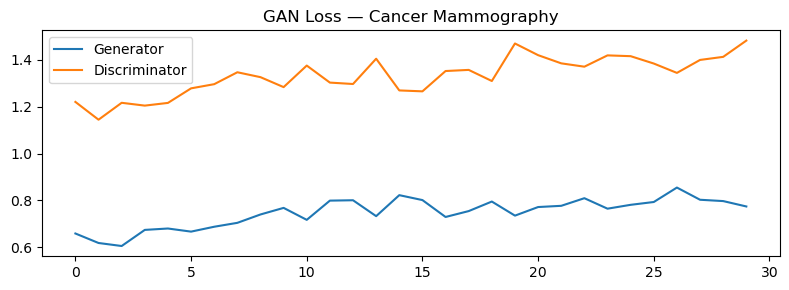

GAN generated 396 synthetic Cancer images ✓


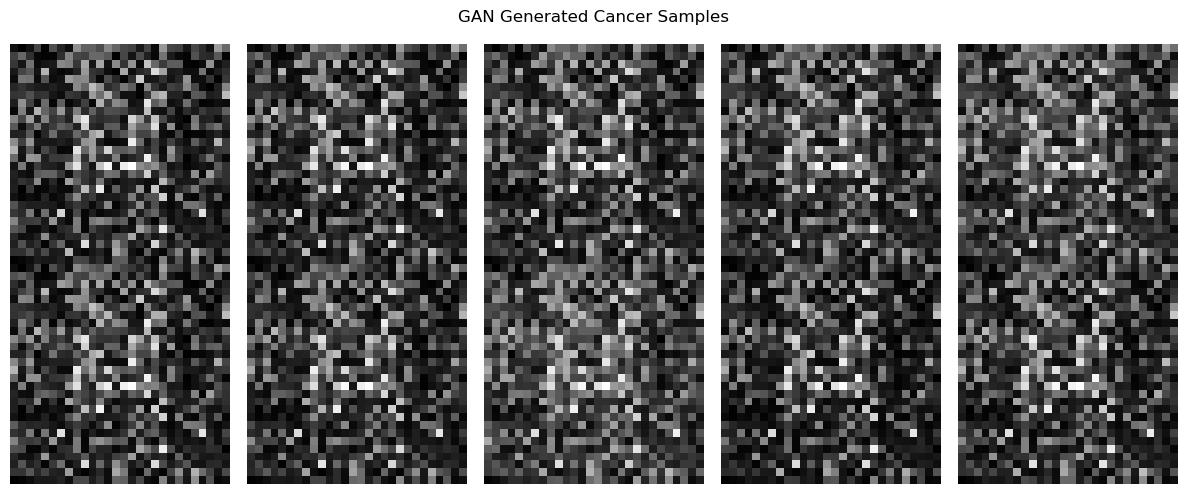

In [166]:
import torch.optim as optim

LATENT_DIM_MAMMO = 100
IMG_FLAT = 28 * 28

class MammoGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM_MAMMO):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512),        nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),       nn.LeakyReLU(0.2),
            nn.Linear(1024, IMG_FLAT),  nn.Tanh()
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

class MammoDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_FLAT, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256),      nn.LeakyReLU(0.2),
            nn.Linear(256, 1),        nn.Sigmoid()
        )
    def forward(self, x): return self.net(x.view(-1, IMG_FLAT))

# آموزش GAN روی Cancer
gan_transform = transforms.Compose([
    transforms.Resize((28, 28)), transforms.Grayscale(1),
    transforms.ToTensor(), transforms.Normalize([0.5], [0.5])
])
cancer_gan_ds     = MammoDataset([(p, l, False) for p, l in cancer_samples_list],
                                   base_transform=gan_transform)
cancer_gan_loader = DataLoader(cancer_gan_ds, batch_size=32, shuffle=True)

mammo_gen  = MammoGenerator().to(device)
mammo_disc = MammoDiscriminator().to(device)
g_opt = optim.Adam(mammo_gen.parameters(),  lr=2e-4, betas=(0.5, 0.999))
d_opt = optim.Adam(mammo_disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

g_losses, d_losses = [], []
for epoch in range(30):
    g_ep, d_ep = 0.0, 0.0
    for imgs, _ in cancer_gan_loader:
        imgs = imgs.to(device); b = imgs.size(0)
        real_lbl = torch.full((b, 1), 0.9, device=device)
        fake_lbl = torch.zeros(b, 1, device=device)

        d_opt.zero_grad()
        z = torch.randn(b, LATENT_DIM_MAMMO, device=device)
        d_loss = bce(mammo_disc(imgs), real_lbl) + bce(mammo_disc(mammo_gen(z).detach()), fake_lbl)
        d_loss.backward(); d_opt.step()

        g_opt.zero_grad()
        z = torch.randn(b, LATENT_DIM_MAMMO, device=device)
        g_loss = bce(mammo_disc(mammo_gen(z)), real_lbl)
        g_loss.backward(); g_opt.step()
        g_ep += g_loss.item(); d_ep += d_loss.item()

    g_losses.append(g_ep/len(cancer_gan_loader))
    d_losses.append(d_ep/len(cancer_gan_loader))
    if (epoch + 1) % 10 == 0:
        print(f"  GAN Epoch [{epoch+1}/30]  G:{g_losses[-1]:.4f}  D:{d_losses[-1]:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(g_losses, label="Generator"); plt.plot(d_losses, label="Discriminator")
plt.title("GAN Loss — Cancer Mammography"); plt.legend(); plt.tight_layout(); plt.show()

# تولید نمونه‌های مصنوعی با GAN
mammo_gen.eval()
with torch.no_grad():
    z = torch.randn(samples_needed, LATENT_DIM_MAMMO, device=device)
    gan_generated = (mammo_gen(z).cpu() + 1) / 2.0   # [-1,1] → [0,1]

print(f"GAN generated {len(gan_generated)} synthetic Cancer images ✓")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(gan_generated[i].squeeze(), cmap="gray"); ax.axis("off")
fig.suptitle("GAN Generated Cancer Samples"); plt.tight_layout(); plt.show()


<div dir="rtl" style="text-align:right">
<p>می‌خواهم ببینم baseline، VAE-balanced و GAN-balanced روی recall سرطان چه فرقی دارند
<p> و نشان می‌دهیم کدام روش بالانس برای این دیتاست بهتر جواب داده است.</p>
</div>


Baseline : 596
VAE bal. : 992
GAN bal. : 992

[1/3] Imbalanced Baseline
  [Imbalanced Baseline] Epoch 5/10  Loss:0.3025  Acc:0.894
  [Imbalanced Baseline] Epoch 10/10  Loss:0.2204  Acc:0.935

=== Imbalanced Baseline ===
  Accuracy:0.9262  F1(Cancer):0.7317  Recall(Cancer):0.6000
              precision    recall  f1-score   support

  Non-Cancer       0.92      0.99      0.96       124
      Cancer       0.94      0.60      0.73        25

    accuracy                           0.93       149
   macro avg       0.93      0.80      0.84       149
weighted avg       0.93      0.93      0.92       149



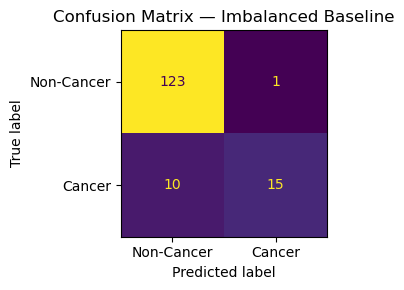


[2/3] VAE Balanced
  [VAE Balanced] Epoch 5/10  Loss:0.1752  Acc:0.953
  [VAE Balanced] Epoch 10/10  Loss:0.1401  Acc:0.958

=== VAE Balanced ===
  Accuracy:0.9060  F1(Cancer):0.7308  Recall(Cancer):0.7600
              precision    recall  f1-score   support

  Non-Cancer       0.95      0.94      0.94       124
      Cancer       0.70      0.76      0.73        25

    accuracy                           0.91       149
   macro avg       0.83      0.85      0.84       149
weighted avg       0.91      0.91      0.91       149



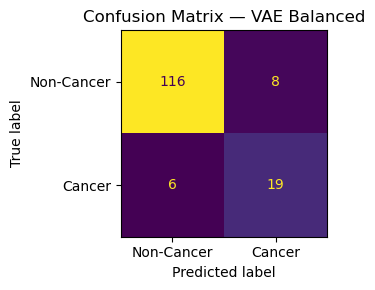


[3/3] GAN Balanced
  [GAN Balanced] Epoch 5/10  Loss:0.1275  Acc:0.959
  [GAN Balanced] Epoch 10/10  Loss:0.0927  Acc:0.971

=== GAN Balanced ===
  Accuracy:0.9530  F1(Cancer):0.8444  Recall(Cancer):0.7600
              precision    recall  f1-score   support

  Non-Cancer       0.95      0.99      0.97       124
      Cancer       0.95      0.76      0.84        25

    accuracy                           0.95       149
   macro avg       0.95      0.88      0.91       149
weighted avg       0.95      0.95      0.95       149



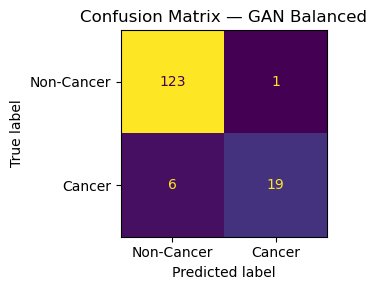

In [167]:
from torch.utils.data import ConcatDataset

class SyntheticTensorDataset(torch.utils.data.Dataset):
    def __init__(self, tensors, label):
        self.tensors = tensors; self.label = label
    def __len__(self): return len(self.tensors)
    def __getitem__(self, idx): return self.tensors[idx], self.label

# VAE balanced
vae_syn_ds       = SyntheticTensorDataset(vae_generated, minority_label)
train_ds_vae     = ConcatDataset([baseline_train_ds, vae_syn_ds])
vae_train_loader = DataLoader(train_ds_vae, batch_size=32, shuffle=True)

# GAN balanced
gan_syn_ds       = SyntheticTensorDataset(gan_generated, minority_label)
train_ds_gan     = ConcatDataset([baseline_train_ds, gan_syn_ds])
gan_train_loader = DataLoader(train_ds_gan, batch_size=32, shuffle=True)

print(f"Baseline : {len(baseline_train_ds)}")
print(f"VAE bal. : {len(train_ds_vae)}")
print(f"GAN bal. : {len(train_ds_gan)}")

print("\n[1/3] Imbalanced Baseline")
model_baseline_fx, res_baseline = train_and_evaluate_full(
    baseline_train_loader, test_loader_mammo, "Imbalanced Baseline")

print("\n[2/3] VAE Balanced")
model_vae_fx, res_vae = train_and_evaluate_full(
    vae_train_loader, test_loader_mammo, "VAE Balanced")

print("\n[3/3] GAN Balanced")
model_gan_fx, res_gan = train_and_evaluate_full(
    gan_train_loader, test_loader_mammo, "GAN Balanced")


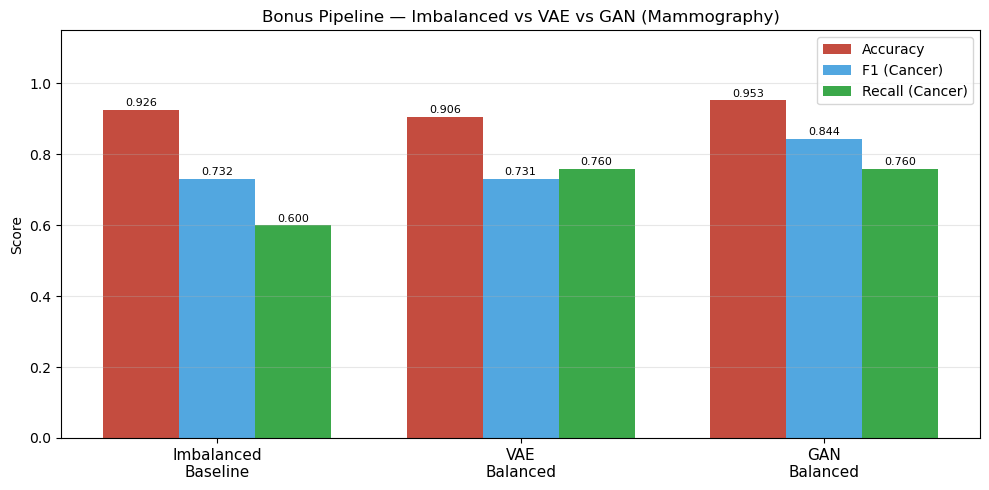


Method                 Accuracy    F1-Cancer   Recall-Cancer
------------------------------------------------------------
Imbalanced               0.9262       0.7317          0.6000
VAE Balanced             0.9060       0.7308          0.7600
GAN Balanced             0.9530       0.8444          0.7600


In [169]:
methods  = ["Imbalanced\nBaseline", "VAE\nBalanced", "GAN\nBalanced"]
results  = [res_baseline, res_vae, res_gan]
metrics  = [("accuracy","Accuracy","#ba2d1d"),
            ("f1","F1 (Cancer)","#3498db"),
            ("recall","Recall (Cancer)","#19992A")]

x, width = np.arange(3), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, (key, label, color) in enumerate(metrics):
    vals = [r[key] for r in results]
    bars = ax.bar(x + (i-1)*width, vals, width, label=label, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{v:.3f}", ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("Bonus Pipeline — Imbalanced vs VAE vs GAN (Mammography)")
ax.legend(); ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

print(f"\n{'Method':<20} {'Accuracy':>10} {'F1-Cancer':>12} {'Recall-Cancer':>15}")
print("-" * 60)
for name, res in zip(["Imbalanced","VAE Balanced","GAN Balanced"], results):
    print(f"{name:<20} {res['accuracy']:>10.4f} {res['f1']:>12.4f} {res['recall']:>15.4f}")


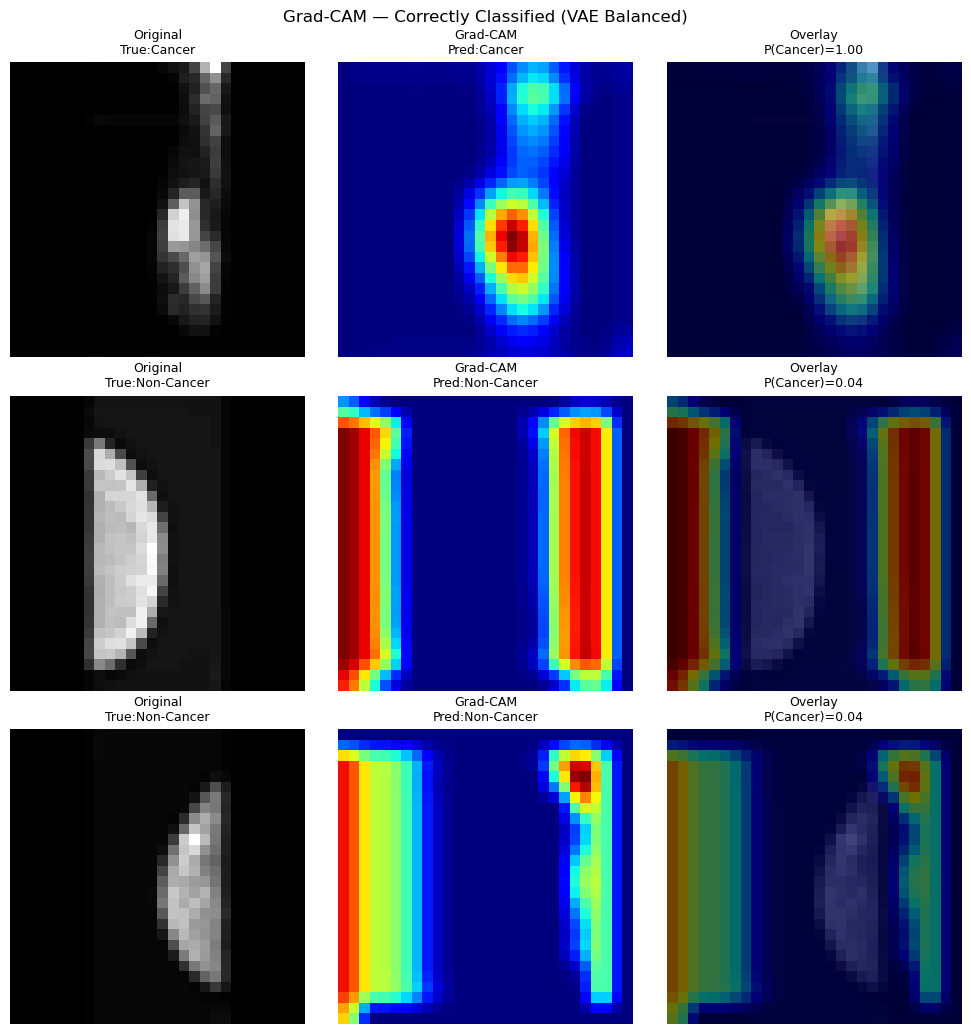

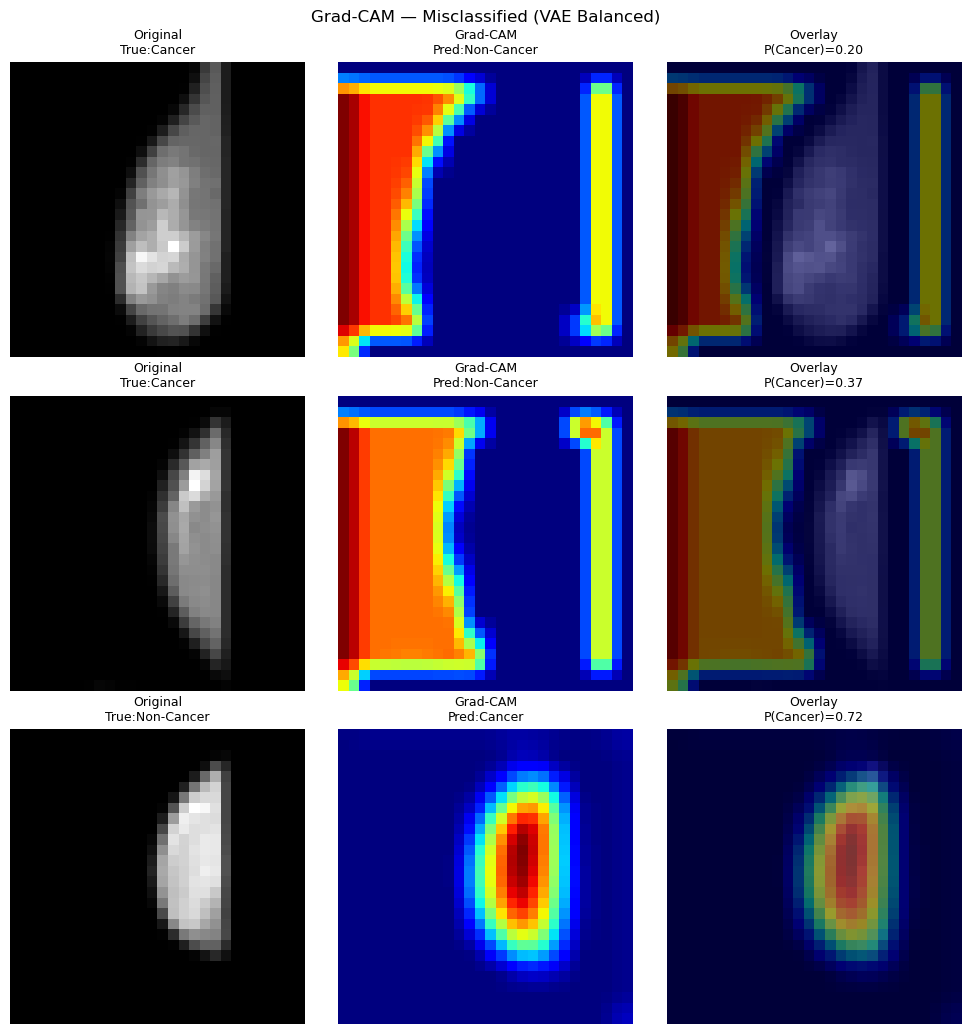

In [170]:
import cv2

def compute_gradcam_mammo(model, input_tensor, target_class=None):
    model.eval()
    inp    = input_tensor.clone().requires_grad_(True)
    output = model(inp)
    if target_class is None: target_class = output.argmax(1).item()
    model.zero_grad()
    output[0, target_class].backward()
    grads   = model.get_activations_gradient()
    acts    = model.last_activation.detach()
    weights = grads.mean(dim=[2,3], keepdim=True)
    cam     = F.relu((weights * acts).sum(dim=1, keepdim=True))
    cam     = cam.squeeze().cpu().numpy()
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    probs   = torch.softmax(output, dim=1).detach().cpu().numpy()[0]
    return cam, output.argmax(1).item(), probs

# بهترین مدل
best_model_mammo = model_vae_fx
class_names = ["Non-Cancer", "Cancer"]

all_imgs_list, all_true_list, all_pred_list = [], [], []
best_model_mammo.eval()
with torch.no_grad():
    for imgs, labels in test_loader_mammo:
        preds = best_model_mammo(imgs.to(device)).argmax(1).cpu()
        all_imgs_list.append(imgs)
        all_true_list.extend(labels.tolist())
        all_pred_list.extend(preds.tolist())

all_imgs_t = torch.cat(all_imgs_list)
y_true_np  = np.array(all_true_list)
y_pred_np  = np.array(all_pred_list)

def plot_gradcam_grid(indices, title):
    if len(indices) == 0:
        print(f"هیچ نمونه‌ای برای '{title}' یافت نشد."); return
    fig, axes = plt.subplots(len(indices), 3, figsize=(10, 3.5*len(indices)))
    if len(indices) == 1: axes = axes[np.newaxis, :]
    for row, idx in enumerate(indices):
        inp = all_imgs_t[idx].unsqueeze(0).to(device)
        true_lbl, pred_lbl = int(y_true_np[idx]), int(y_pred_np[idx])
        cam, _, probs = compute_gradcam_mammo(best_model_mammo, inp, pred_lbl)
        orig    = all_imgs_t[idx].squeeze().numpy()
        cam_r   = cv2.resize(cam, (28, 28))
        overlay = plt.cm.jet(cam_r)[:,:,:3]*0.45 + np.stack([orig]*3,-1)*0.55
        for j, (im, cmap, ttl) in enumerate([
            (orig, "gray", f"Original\nTrue:{class_names[true_lbl]}"),
            (cam_r, "jet", f"Grad-CAM\nPred:{class_names[pred_lbl]}"),
            (overlay, None, f"Overlay\nP(Cancer)={probs[1]:.2f}")
        ]):
            axes[row,j].imshow(im, cmap=cmap); axes[row,j].set_title(ttl, fontsize=9)
            axes[row,j].axis("off")
    fig.suptitle(title, fontsize=12); plt.tight_layout(); plt.show()

correct_idx = np.where(y_true_np == y_pred_np)[0][:3]
wrong_idx   = np.where(y_true_np != y_pred_np)[0][:3]
plot_gradcam_grid(correct_idx, "Grad-CAM — Correctly Classified (VAE Balanced)")
plot_gradcam_grid(wrong_idx,   "Grad-CAM — Misclassified (VAE Balanced)")


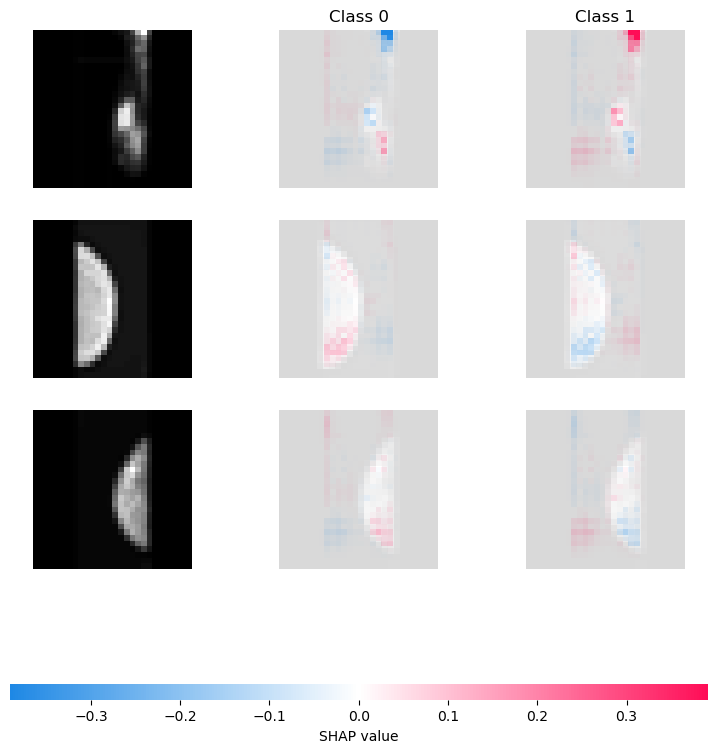

In [171]:
import shap

best_model_mammo.eval()
all_test_imgs = torch.cat([imgs for imgs, _ in test_loader_mammo])
background    = all_test_imgs[:50].to(device)
to_explain    = all_test_imgs[:3].to(device)

explainer   = shap.GradientExplainer(best_model_mammo, background)
shap_values = explainer.shap_values(to_explain)

# handle new vs old SHAP API
if isinstance(shap_values, list):
    sv_list = shap_values
else:
    sv_list = [shap_values[..., i] for i in range(shap_values.shape[-1])]

shap_numpy   = [np.swapaxes(np.swapaxes(sv, 1, -1), 1, 2) for sv in sv_list]
images_numpy = np.swapaxes(np.swapaxes(to_explain.cpu().numpy(), 1, -1), 1, 2)

shap.image_plot(shap_numpy, images_numpy,
                labels=[f"Class {i}" for i in range(len(sv_list))])
